In [29]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..').resolve()))

warnings.filterwarnings('ignore', category=UserWarning, module='seaborn')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

from monitorviz.io import load_collection
from monitorviz.transforms import RunCollection
from monitorviz.viz import (
    setup_style, correlation_heatmap, pareto_panel_multi,
    phase_breakdown_stacked, throttling_heatmap,
    hw_distributions_panel, temp_freq_dual,
    cpu_memory_dual_phases,
)
setup_style()

DATA_BASE = Path('../data/tfg-data')
EXP_FAN   = DATA_BASE / 'E0-FAN'   / 'results'
EXP_NOFAN = DATA_BASE / 'E0-NOFAN' / 'results'

_runs_fan_all   = load_collection(EXP_FAN).runs   if EXP_FAN.exists()   else []
_runs_nofan_all = load_collection(EXP_NOFAN).runs if EXP_NOFAN.exists() else []

# Filtrar solo LLAMA.cpp antes de construir la colección
ENGINE = 'LLAMA'
runs_fan   = [r for r in _runs_fan_all   if r.summary.inference_engine == ENGINE]
runs_nofan = [r for r in _runs_nofan_all if r.summary.inference_engine == ENGINE]

coll = RunCollection(runs_fan + runs_nofan)

summary = coll.summary_df()
hw_df   = coll.hw_metrics_df()
pm_df   = coll.prompt_metrics_df()

print(f'Engine: {ENGINE}')
print(f'Runs cargados: {len(coll.runs)}')
print(f'  · Con ventilador:    {len(runs_fan)}')
print(f'  · Sin ventilador:    {len(runs_nofan)}')
print(f'  · Runs en summary:   {len(summary)}')
n_valid = len(pm_df[~pm_df["is_empty_generation"]]) if not pm_df.empty else 0
print(f'  · Prompts válidos:   {n_valid}')

Engine: LLAMA
Runs cargados: 12
  · Con ventilador:    6
  · Sin ventilador:    6
  · Runs en summary:   12
  · Prompts válidos:   178


1# E0 — Comparativa baseline entre modelos

## Pregunta de investigación
¿Qué modelo LLM ofrece el mejor compromiso rendimiento/eficiencia en
una Raspberry Pi 5 en condiciones de inferencia estándar?
¿Cómo afecta la refrigeración activa (ventilador) al rendimiento sostenido?

## Hipótesis
- Los modelos más pequeños (1B) serán más rápidos pero con menor calidad.
- El ventilador reducirá el throttling térmico y mejorará el throughput sostenido.
- La potencia media será similar entre modelos (limitada por el SoC),
  pero la energía por token variará según la velocidad de cada modelo.

## Configuración del experimento
| Parámetro       | Valor fijo                                          |
|-----------------|-----------------------------------------------------|
| batch_size      | 512                                                 |
| context_size    | 2048                                                |
| quantization    | Q4_K_M                                              |
| temperature     | 0.7                                                 |
| num_prompts     | 15 (IFEval)                                         |
| hardware        | Raspberry Pi 5 (BCM2712, 8 GB LPDDR4X)             |

| Variable        | Valores                                             |
|-----------------|-----------------------------------------------------|
| modelo          | Ministral-3B, Llama3.2-1B, Llama3.2-3B,           |
|                 | DeepSeek-Qwen-1.5B, Gemma3n-e2b                    |
| refrigeración   | Con ventilador (FAN) / Sin ventilador (NOFAN)       |

## 1. Validación de datos

In [57]:
if not summary.empty:
    _cols = [c for c in ['model_label', 'fan', 'engine',
                          'n_prompts', 'n_empty_generations', 'throttled_ratio']
             if c in summary.columns]
    display(summary[_cols].sort_values(['model_label', 'fan']).reset_index(drop=True))

    # Matriz del experimento: modelos × fan
    if 'tokens_per_s_mean' in summary.columns:
        matrix = summary.pivot_table(
            index='model_label', columns='fan',
            values='tokens_per_s_mean', aggfunc='count'
        ).fillna(0).astype(int)
        print('\nRuns por modelo × refrigeración (count):')
        display(matrix)

    alertas = summary[
        (summary.get('n_empty_generations', pd.Series(0, index=summary.index)) > 0) |
        (summary.get('throttled_ratio', pd.Series(0.0, index=summary.index)) > 0.8)
    ]
    if not alertas.empty:
        print('\n⚠️ Alertas:')
        _acols = [c for c in ['model_label', 'fan', 'n_empty_generations', 'throttled_ratio']
                  if c in alertas.columns]
        display(alertas[_acols])
    else:
        print('\n✅ Sin alertas.')
else:
    print('Sin datos cargados.')


,model_label,fan,engine,n_prompts,n_empty_generations,throttled_ratio
0,DeepSeek-R1-1.5B (L),False,LLAMA,15,0,0.999505
1,DeepSeek-R1-1.5B (L),True,LLAMA,15,0,0.000000
2,Llama-3.2-1B (L),False,LLAMA,15,0,0.999285
3,Llama-3.2-1B (L),True,LLAMA,15,0,0.000000
4,Llama-3.2-3B (L),False,LLAMA,15,0,0.999588
5,Llama-3.2-3B (L),True,LLAMA,15,0,0.000000
6,gemma (L),False,LLAMA,15,0,0.998119
7,gemma (L),True,LLAMA,15,0,0.000000
8,granite (L),False,LLAMA,15,0,0.997670
9,granite (L),True,LLAMA,15,0,0.000000



Runs por modelo × refrigeración (count):


fan,False,True
model_label,,
DeepSeek-R1-1.5B (L),1,1
Llama-3.2-1B (L),1,1
Llama-3.2-3B (L),1,1
gemma (L),1,1
granite (L),1,1
ministral (L),1,1



⚠️ Alertas:


,model_label,fan,n_empty_generations,throttled_ratio
0,ministral (L),True,1,0.000000
6,ministral (L),False,1,0.997808
7,Llama-3.2-3B (L),False,0,0.999588
8,Llama-3.2-1B (L),False,0,0.999285
9,granite (L),False,0,0.997670
10,gemma (L),False,0,0.998119
11,DeepSeek-R1-1.5B (L),False,0,0.999505


## 2. Evolución temporal del hardware

Timelines de temperatura, potencia y swap durante el run completo,
agrupados por modelo y refrigeración. Permiten identificar el momento
en que aparece el throttling térmico y su evolución.

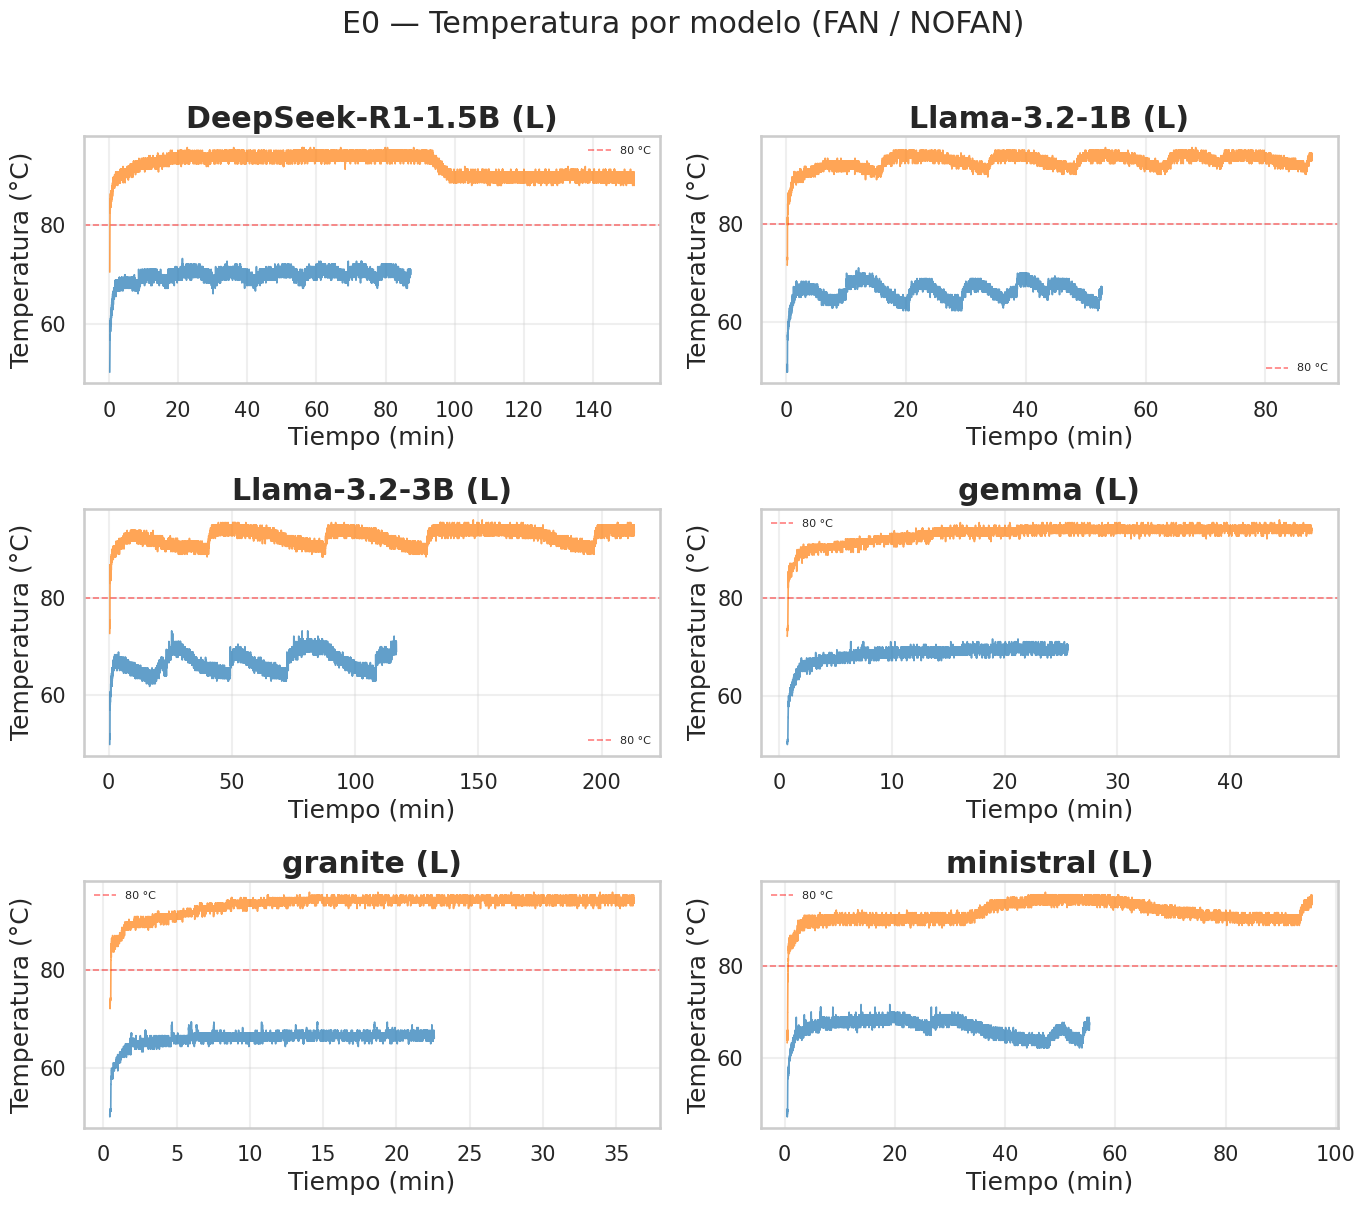

In [31]:
def _plot_timeline(hw_data, y_col, ylabel, suptitle, hline=None):
    models = sorted(hw_data['model_label'].unique())
    if not models:
        print(f'Sin datos para {suptitle}')
        return
    ncols = 2
    nrows = (len(models) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        sub = hw_data[hw_data['model_label'] == model]
        if sub.empty:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center',
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        t_max = sub['t_rel_s'].max()
        x_vals = sub['t_rel_s'] / 60 if t_max > 1800 else sub['t_rel_s']
        ax.set_xlabel('Tiempo (min)' if t_max > 1800 else 'Tiempo (s)')
        for rid in sub['run_id'].unique():
            s = sub[sub['run_id'] == rid].sort_values('t_rel_s')
            xv = s['t_rel_s'] / 60 if t_max > 1800 else s['t_rel_s']
            ax.plot(xv.values, s[y_col].values, alpha=0.7, lw=1.2)
        if hline is not None:
            ax.axhline(hline, ls='--', color='red', alpha=0.5, lw=1.2,
                       label=f'{hline} °C')
            ax.legend(fontsize=8)
        ax.set_ylabel(ylabel)
        ax.set_title(model, fontweight='bold')
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle(suptitle, y=1.01)
    fig.tight_layout()
    plt.show()

if not hw_df.empty:
    _plot_timeline(hw_df, 'temperature_c', 'Temperatura (°C)',
                   'E0 — Temperatura por modelo (FAN / NOFAN)', hline=80)
else:
    print('Sin datos de hardware para timelines de temperatura.')


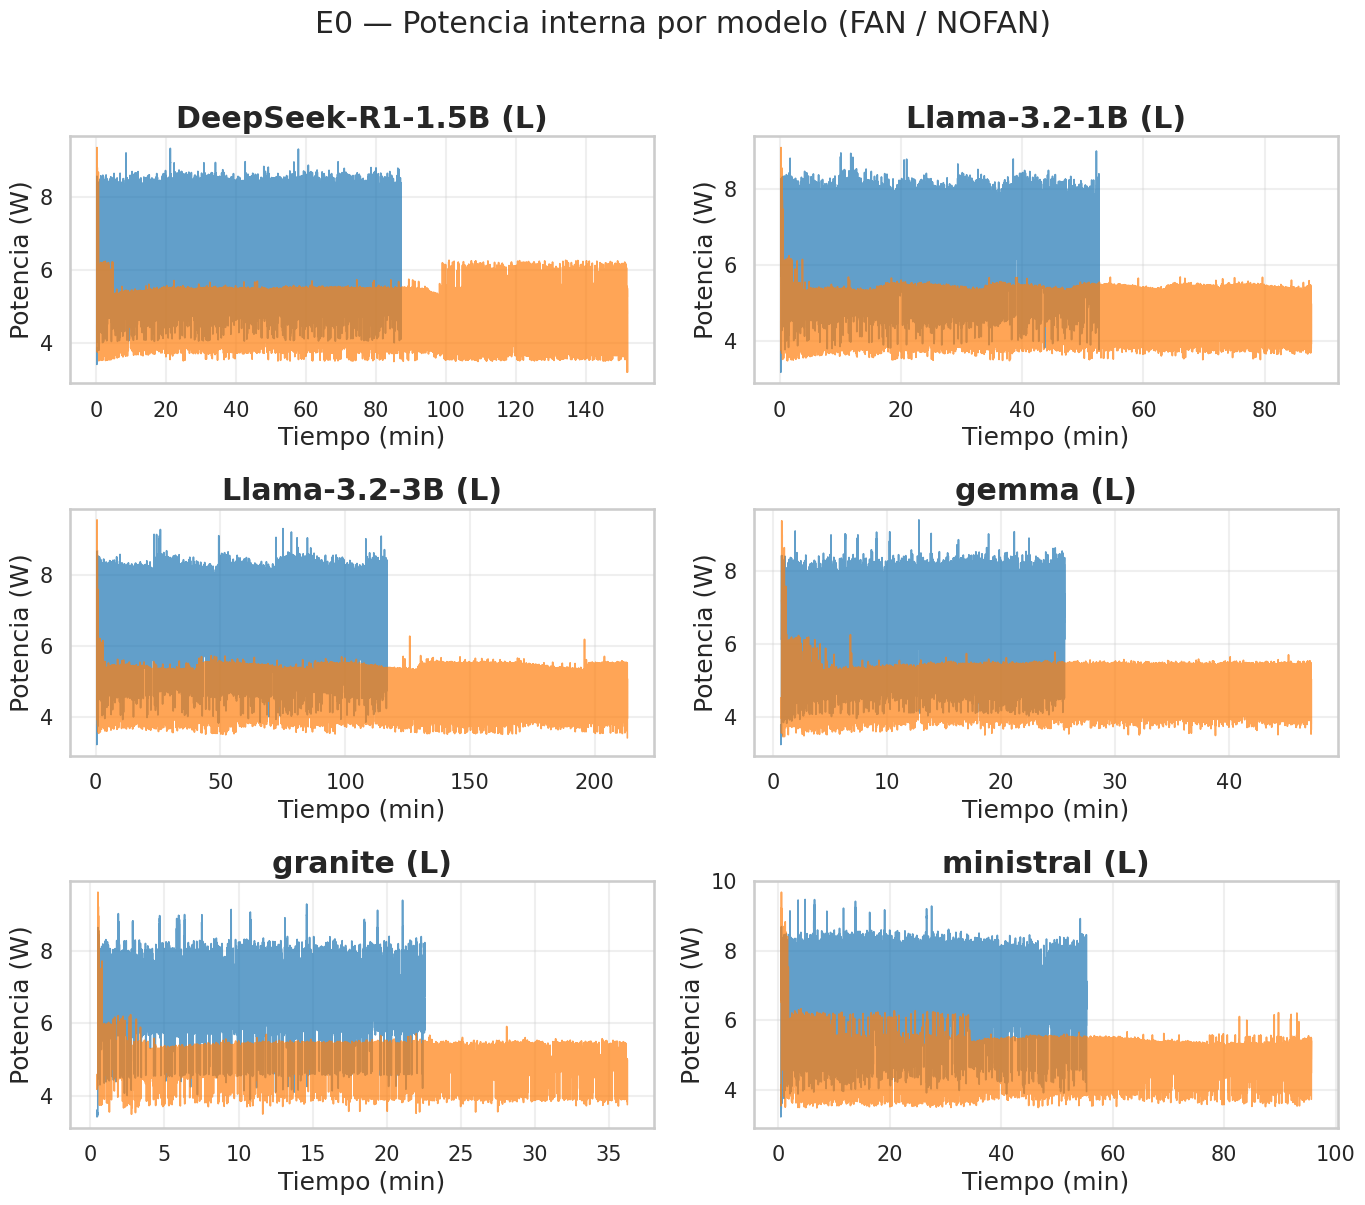

In [32]:
if not hw_df.empty:
    _plot_timeline(hw_df, 'internal_power_w', 'Potencia (W)',
                   'E0 — Potencia interna por modelo (FAN / NOFAN)')
else:
    print('Sin datos de hardware para timelines de potencia.')


Run representativo (más throttleado): Llama-3.2-3B-Instruct-Q4_K_M


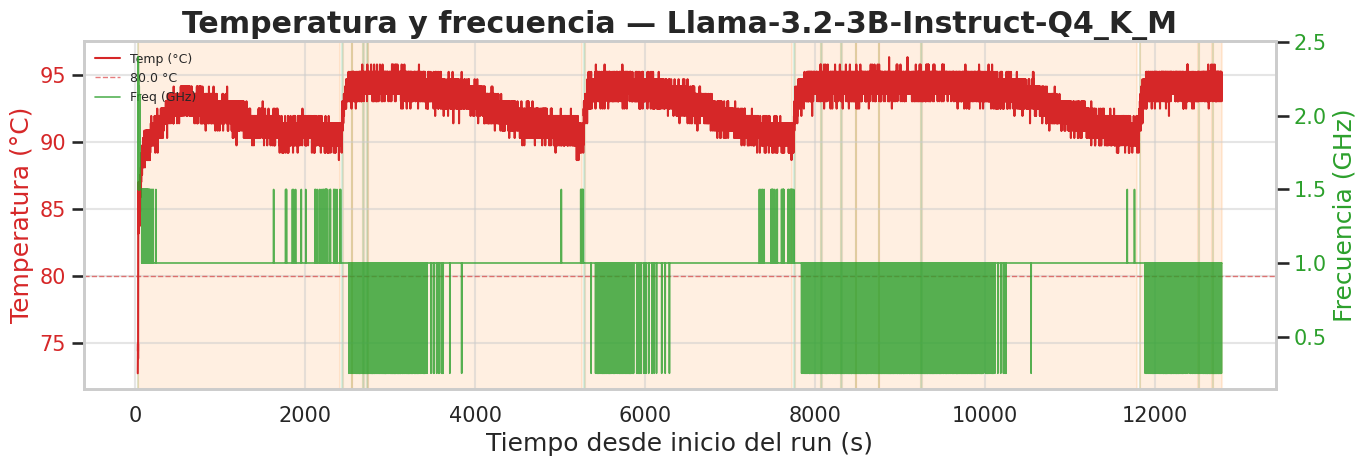

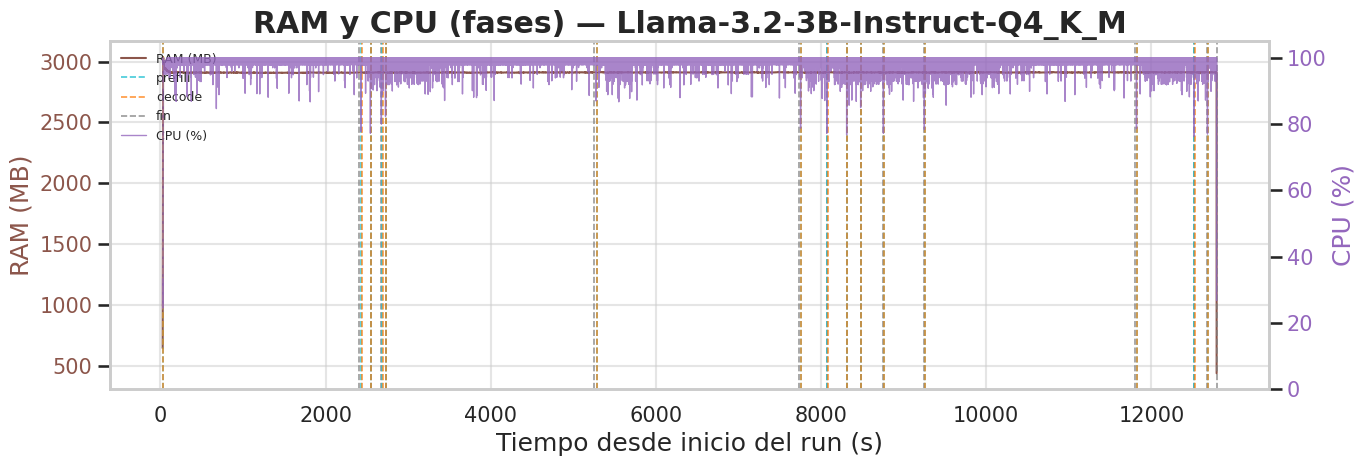

In [33]:
if not hw_df.empty and not summary.empty and 'throttled_ratio' in summary.columns:
    _best = summary.sort_values('throttled_ratio', ascending=False)
    _rep_id = _best['run_id'].iloc[0] if 'run_id' in _best.columns else None
    if _rep_id:
        run_rep = next((r for r in coll.runs if r.run_id == _rep_id), None)
        hw_rep  = hw_df[hw_df['run_id'] == _rep_id]
        if run_rep is not None and not hw_rep.empty:
            print(f'Run representativo (más throttleado): {run_rep.model_short}')
            try:
                fig = temp_freq_dual(hw_rep, run_rep)
                plt.show()
            except Exception as e:
                print(f'temp_freq_dual: {e}')
            try:
                fig = cpu_memory_dual_phases(hw_rep, run_rep)
                plt.show()
            except Exception as e:
                print(f'cpu_memory_dual_phases: {e}')
        else:
            print('Run representativo no encontrado.')
    else:
        print('Sin run_id disponible.')
else:
    print('Sin datos de hardware o throttled_ratio para run representativo.')


## 3. Distribuciones del entorno hardware

Distribuciones estadísticas de las métricas de hardware agregando todas
las muestras de todos los runs del experimento.

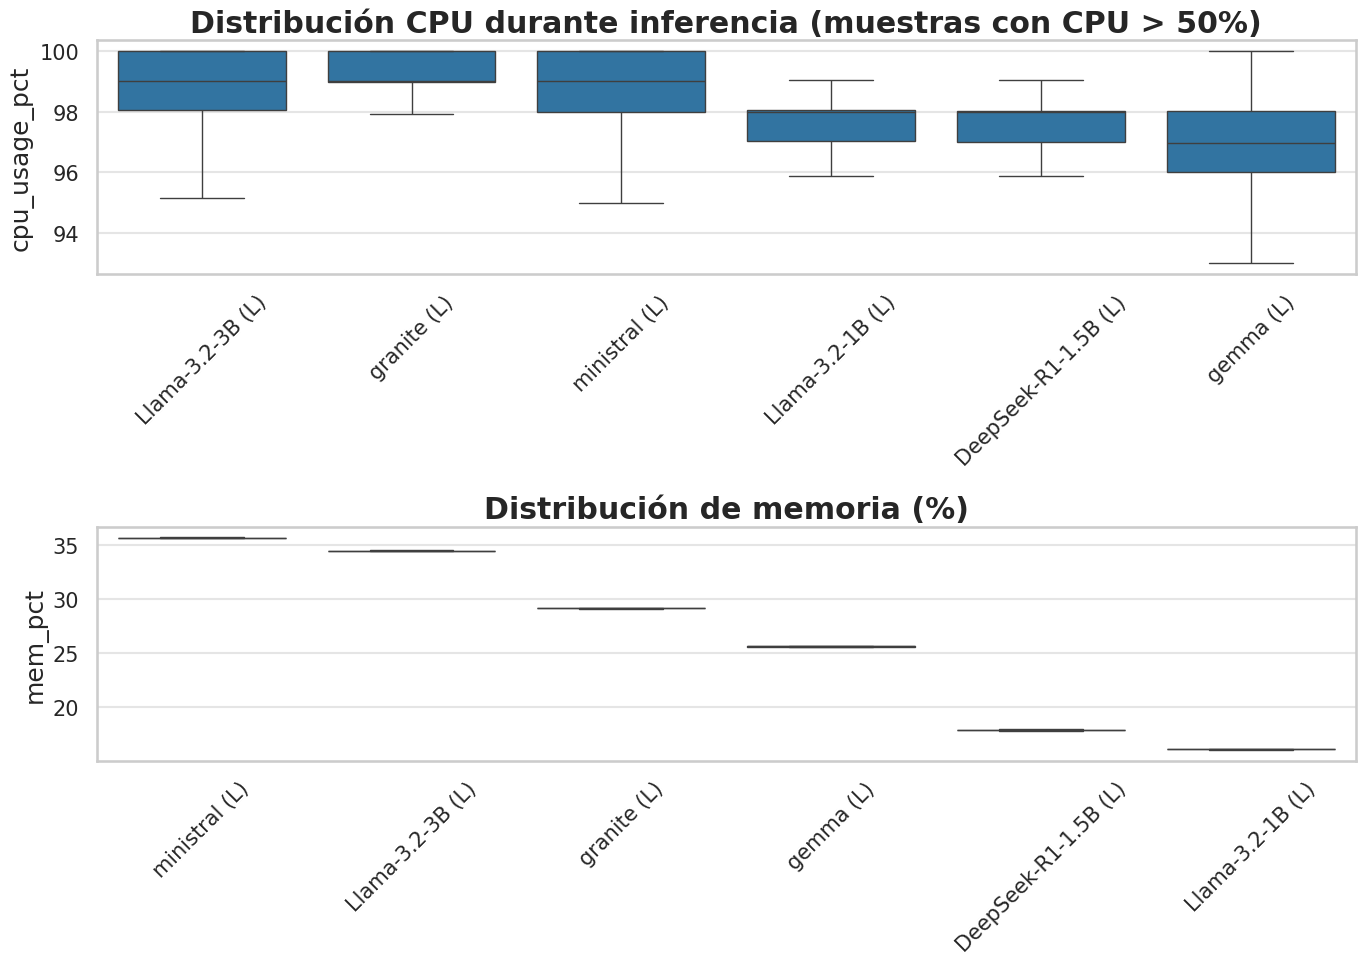

In [34]:
if not hw_df.empty:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    active = hw_df[hw_df['cpu_usage_pct'] > 50].copy()
    if not active.empty:
        order = (active.groupby('model_label')['cpu_usage_pct']
                 .median().sort_values(ascending=False).index.tolist())
        sns.boxplot(data=active, x='model_label', y='cpu_usage_pct',
                    order=order, showfliers=False, ax=axes[0])
        axes[0].set_title('Distribución CPU durante inferencia (muestras con CPU > 50%)')
        axes[0].set_xlabel('')
        axes[0].tick_params(axis='x', rotation=45)
    if 'mem_pct' in hw_df.columns:
        order_mem = (hw_df.groupby('model_label')['mem_pct']
                     .median().sort_values(ascending=False).index.tolist())
        sns.boxplot(data=hw_df, x='model_label', y='mem_pct',
                    order=order_mem, showfliers=False, ax=axes[1])
        axes[1].set_title('Distribución de memoria (%)')
        axes[1].set_xlabel('')
        axes[1].tick_params(axis='x', rotation=45)
    fig.tight_layout()
    plt.show()
else:
    print('Sin datos de hardware para boxplots.')


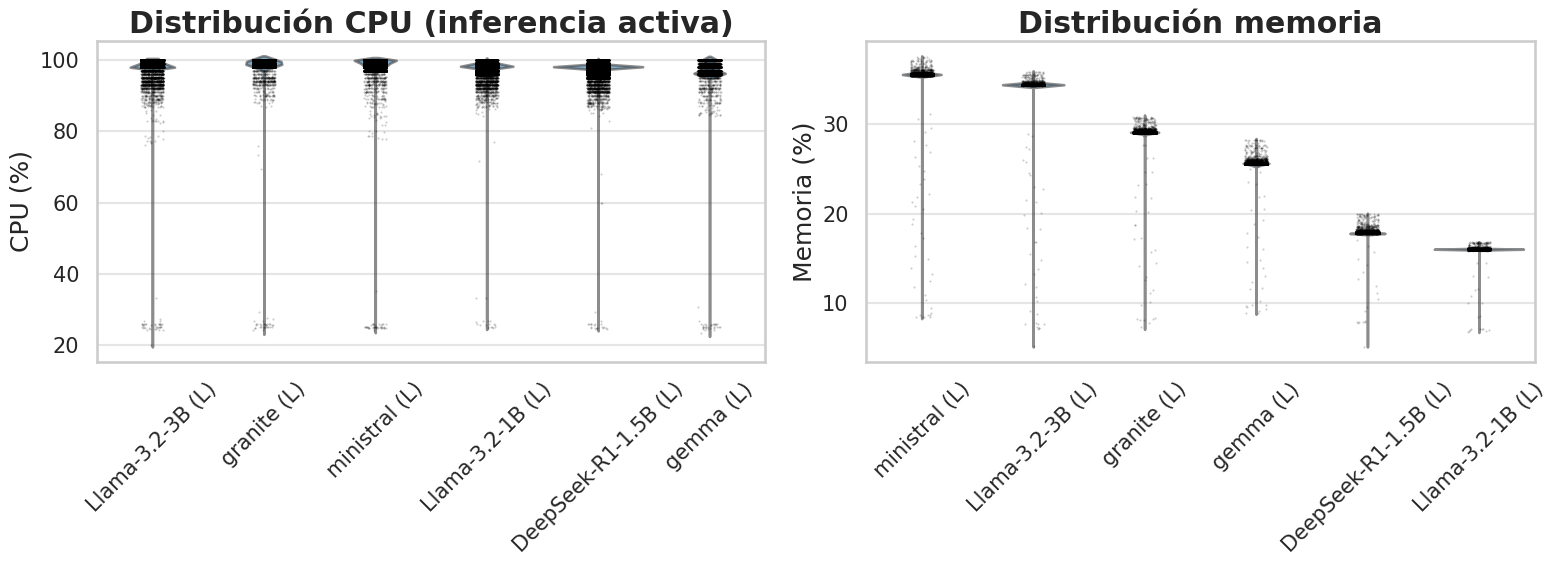

In [35]:
if not hw_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, (col, ylabel, title) in zip(axes, [
        ('cpu_usage_pct', 'CPU (%)',     'Distribución CPU (inferencia activa)'),
        ('mem_pct',       'Memoria (%)', 'Distribución memoria'),
    ]):
        if col not in hw_df.columns:
            ax.text(0.5, 0.5, f'{col} no disponible', ha='center', va='center',
                    transform=ax.transAxes)
            continue
        data = hw_df[hw_df['cpu_usage_pct'] > 10].copy() if 'cpu' in col else hw_df.copy()
        if data.empty:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center',
                    transform=ax.transAxes)
            continue
        order = (data.groupby('model_label')[col]
                 .median().sort_values(ascending=False).index.tolist())
        sns.violinplot(data=data, x='model_label', y=col,
                       order=order, inner=None, alpha=0.6, ax=ax)
        sns.stripplot(data=data, x='model_label', y=col,
                      order=order, size=1.5, alpha=0.2, color='black', ax=ax)
        ax.set_title(title)
        ax.set_xlabel('')
        ax.set_ylabel(ylabel)
        ax.tick_params(axis='x', rotation=45)
    fig.tight_layout()
    plt.show()
else:
    print('Sin datos de hardware para violines.')


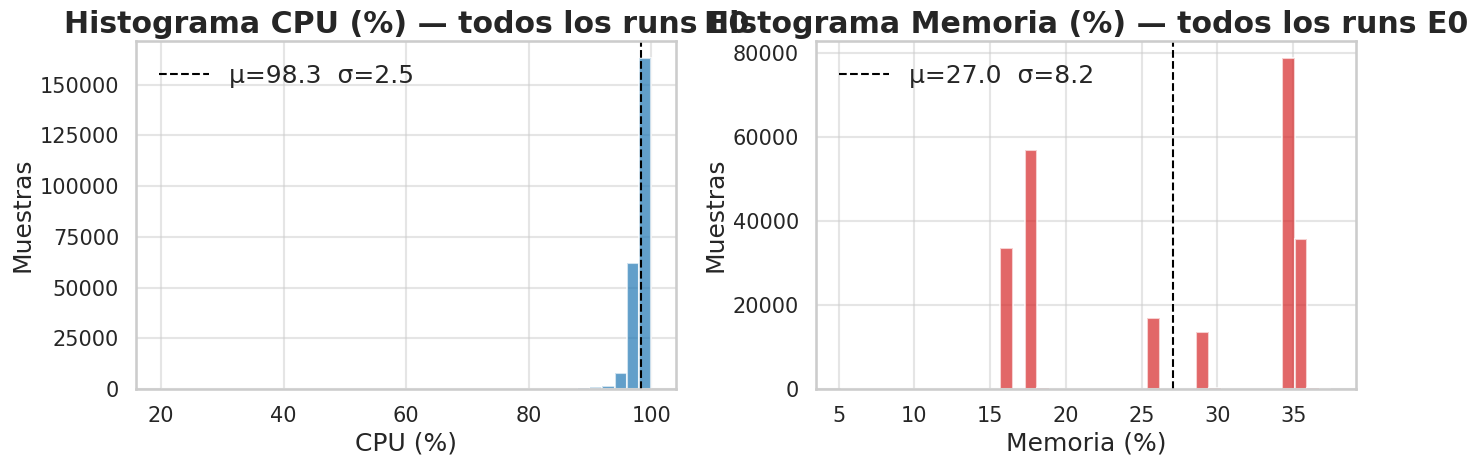

In [36]:
if not hw_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (col, xlabel, color) in zip(axes, [
        ('cpu_usage_pct', 'CPU (%)',     'tab:blue'),
        ('mem_pct',       'Memoria (%)', 'tab:red'),
    ]):
        if col not in hw_df.columns:
            ax.set_visible(False)
            continue
        data = hw_df[hw_df['cpu_usage_pct'] > 10][col].dropna()
        if data.empty:
            ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center',
                    transform=ax.transAxes)
            continue
        ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
        ax.axvline(data.mean(), color='black', ls='--', lw=1.5,
                   label=f'\u03bc={data.mean():.1f}  \u03c3={data.std():.1f}')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Muestras')
        ax.set_title(f'Histograma {xlabel} \u2014 todos los runs E0')
        ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print('Sin datos de hardware para histogramas.')


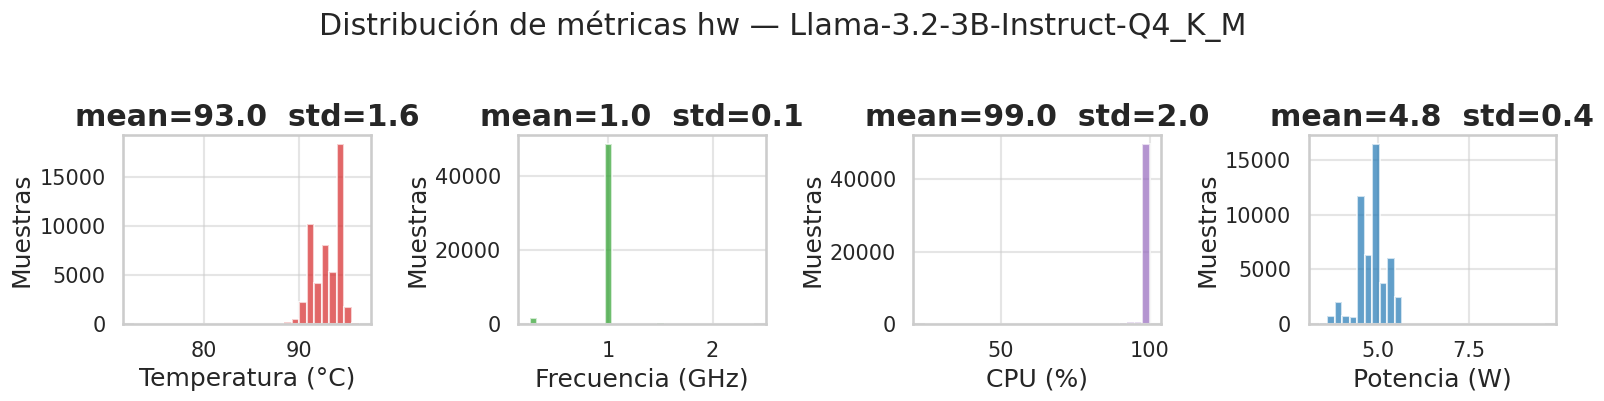

In [37]:
if not hw_df.empty and not summary.empty and 'throttled_ratio' in summary.columns:
    _rep_id = summary.sort_values('throttled_ratio', ascending=False)['run_id'].iloc[0]
    hw_rep  = hw_df[hw_df['run_id'] == _rep_id]
    run_rep = next((r for r in coll.runs if r.run_id == _rep_id), None)
    if run_rep is not None and not hw_rep.empty:
        try:
            fig = hw_distributions_panel(hw_rep, run_rep)
            plt.show()
        except Exception as e:
            print(f'hw_distributions_panel: {e}')
    else:
        print('Run representativo no encontrado para hw_distributions_panel.')
else:
    print('Sin datos para panel de histogramas hw.')


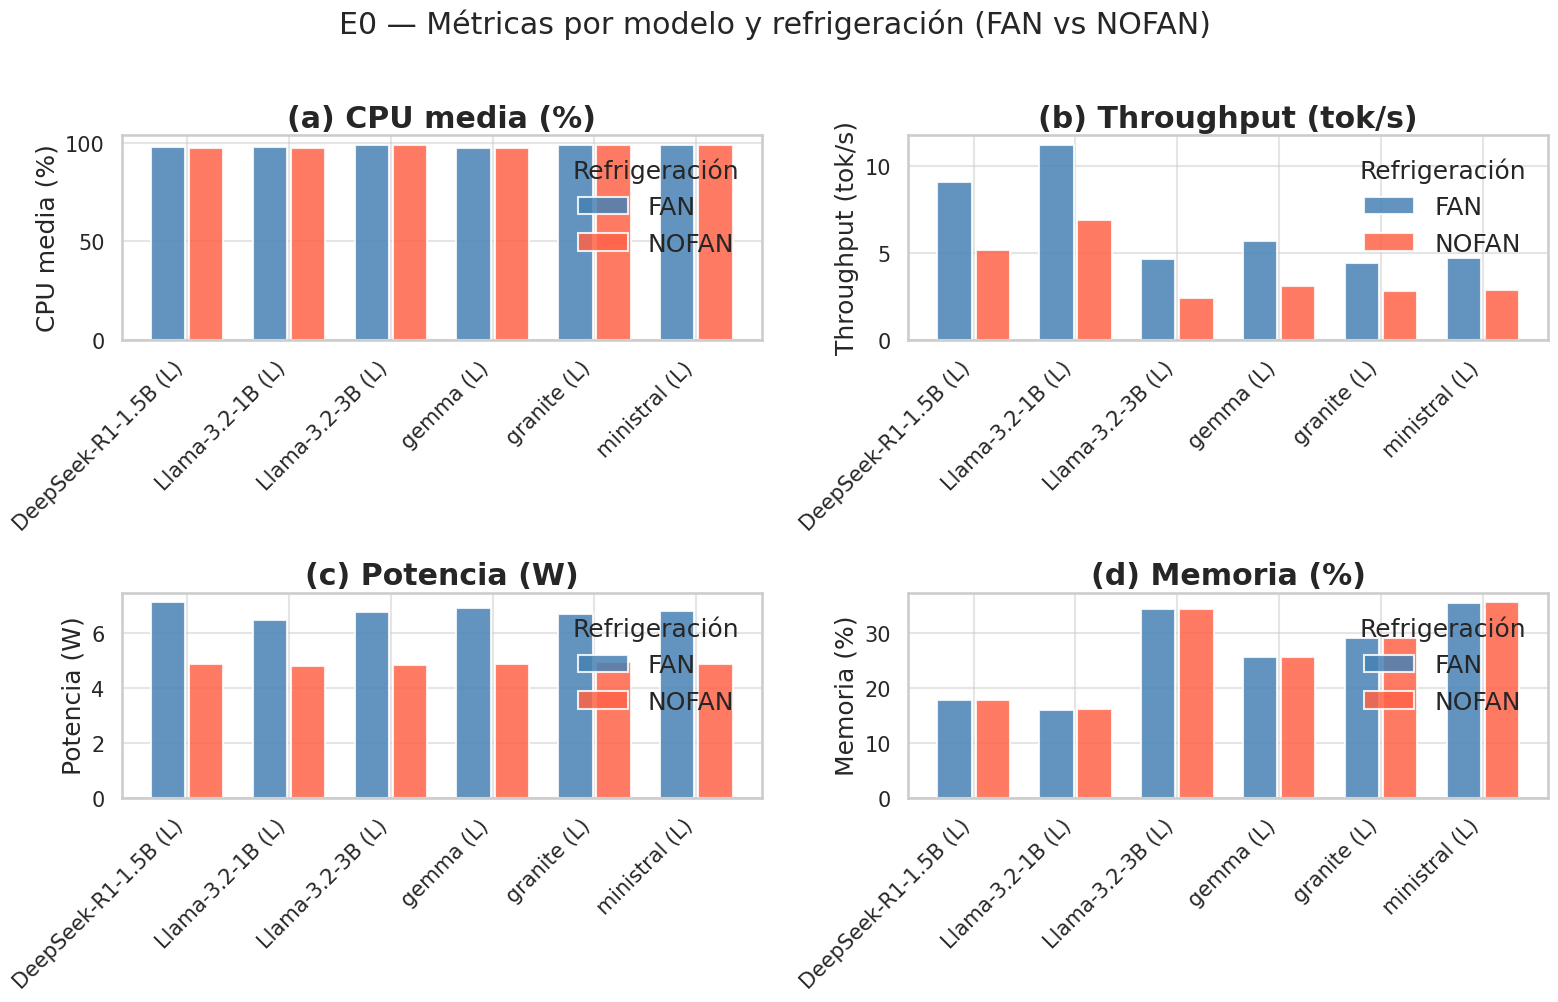

In [38]:
if not hw_df.empty and not pm_df.empty and not summary.empty:
    pm_valid_tmp = pm_df[~pm_df['is_empty_generation']].copy()

    hw_rows = []
    for _, row in summary.iterrows():
        rid   = row.get('run_id')
        fan_v = row.get('fan', False)
        hw_r  = hw_df[hw_df['run_id'] == rid] if rid else pd.DataFrame()
        pm_r  = pm_valid_tmp[pm_valid_tmp['run_id'] == rid] if rid else pd.DataFrame()
        if hw_r.empty:
            continue
        active_r = hw_r[hw_r['cpu_usage_pct'] > 50]
        hw_rows.append({
            'model_label': row['model_label'],
            'fan': 'FAN' if fan_v else 'NOFAN',
            'cpu_pct':  active_r['cpu_usage_pct'].mean() if not active_r.empty else float('nan'),
            'tokens_s': pm_r['tokens_per_second'].mean() if not pm_r.empty else float('nan'),
            'power_w':  hw_r['internal_power_w'].mean(),
            'mem_pct':  hw_r['mem_pct'].mean() if 'mem_pct' in hw_r else float('nan'),
        })

    if hw_rows:
        hw_sum = pd.DataFrame(hw_rows)
        METRICS = [
            ('cpu_pct',  'CPU media (%)',       '(a)'),
            ('tokens_s', 'Throughput (tok/s)', '(b)'),
            ('power_w',  'Potencia (W)',        '(c)'),
            ('mem_pct',  'Memoria (%)',         '(d)'),
        ]
        models  = sorted(hw_sum['model_label'].unique())
        configs = sorted(hw_sum['fan'].unique())
        x_pos   = np.arange(len(models))
        n_cfg   = len(configs)
        width   = 0.75 / max(n_cfg, 1)
        palette = ['steelblue', 'tomato', 'seagreen', 'goldenrod']

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        axes_flat = axes.flatten()
        for ax, (col, ylabel, label) in zip(axes_flat, METRICS):
            data = hw_sum.dropna(subset=[col])
            for j, (cfg, color) in enumerate(zip(configs, palette)):
                vals = [data[(data['model_label'] == m) & (data['fan'] == cfg)][col].mean()
                        if not data[(data['model_label'] == m) & (data['fan'] == cfg)].empty
                        else float('nan')
                        for m in models]
                offset = (j - n_cfg / 2 + 0.5) * width
                ax.bar(x_pos + offset, vals, width * 0.9,
                       label=cfg, color=color, alpha=0.85)
            ax.set_xticks(x_pos)
            ax.set_xticklabels(models, rotation=45, ha='right')
            ax.set_ylabel(ylabel)
            ax.set_title(f'{label} {ylabel}', fontweight='bold')
            ax.legend(title='Refrigeración')
        fig.suptitle('E0 — Métricas por modelo y refrigeración (FAN vs NOFAN)', y=1.01)
        fig.tight_layout()
        plt.show()
    else:
        print('Sin datos para grouped bar chart.')
else:
    print('Sin datos suficientes para grouped bar chart.')


## 4. Métricas de inferencia

Distribución de las métricas de rendimiento por prompt para cada
configuración del experimento.

In [39]:
def _plot_metric(df, metric, ylabel='', title='', unit_label=''):
    """Barplot (n>=3) o barh (n<3) de una métrica por model_label."""
    data = df.dropna(subset=[metric]).copy()
    if data.empty:
        print(f'Sin datos para {metric}')
        return
    counts = data.groupby('model_label')[metric].count()
    min_n  = int(counts.min()) if not counts.empty else 0
    order  = data.groupby('model_label')[metric].mean()\
                 .sort_values().index.tolist()
    full_title = f'{title}' + (f' ({unit_label})' if unit_label else '')
    if min_n >= 3:
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(data=data, x='model_label', y=metric, order=order, ax=ax)
        ax.set_xlabel('')
        ax.set_ylabel(unit_label or ylabel or metric)
        ax.set_title(full_title)
        ax.tick_params(axis='x', rotation=45)
        fig.tight_layout()
    else:
        means = data.groupby('model_label')[metric].mean().reindex(order)
        fig, ax = plt.subplots(figsize=(10, max(5, len(means) * 0.6)))
        ax.barh(range(len(means)), means.values, alpha=0.8)
        ax.set_yticks(range(len(means)))
        ax.set_yticklabels(means.index)
        ax.set_xlabel(unit_label or ylabel or metric)
        ax.set_title(full_title)
        fig.tight_layout()
    plt.show()


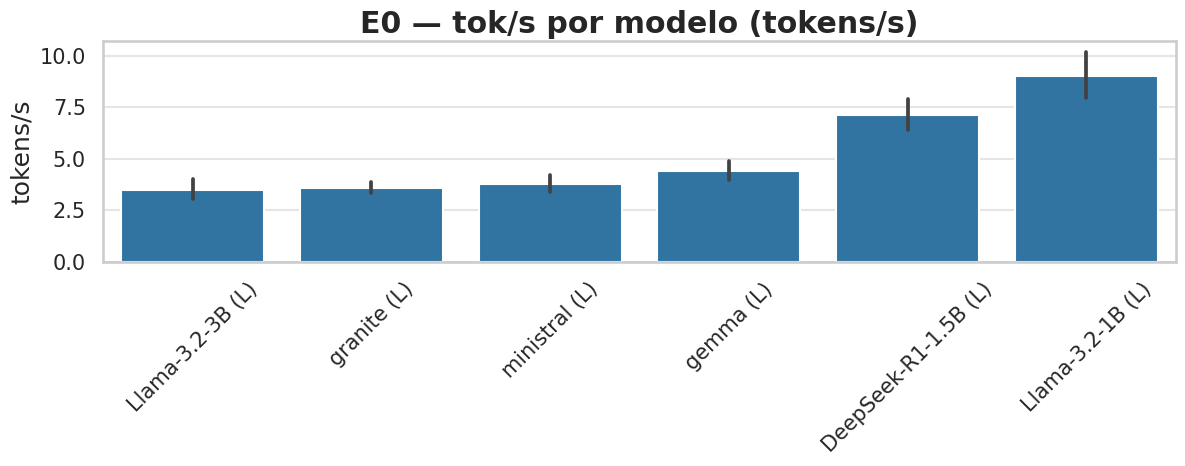

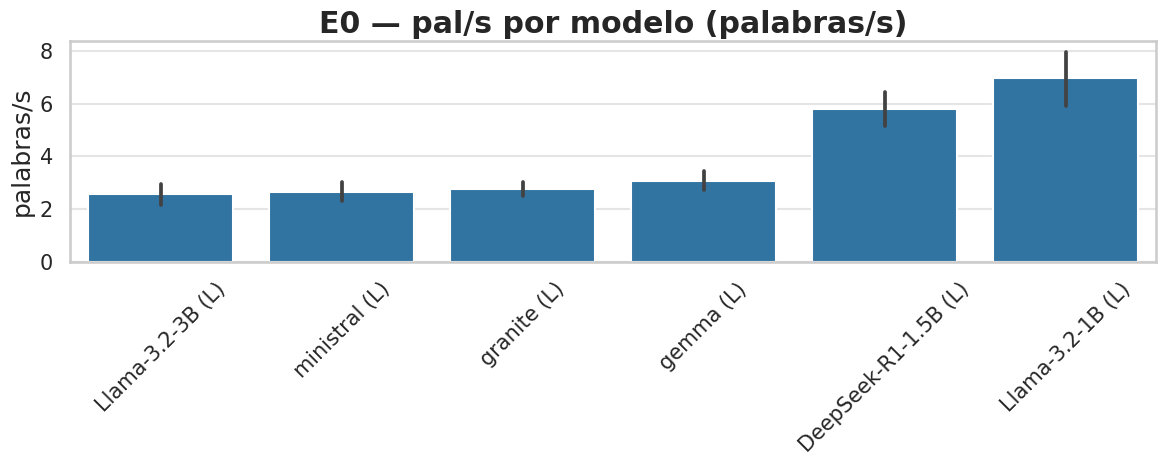

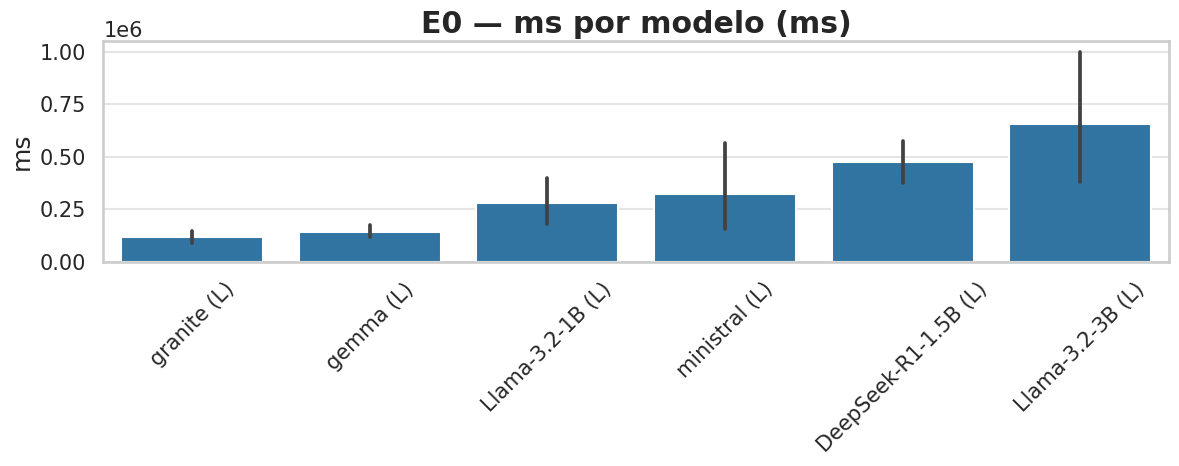

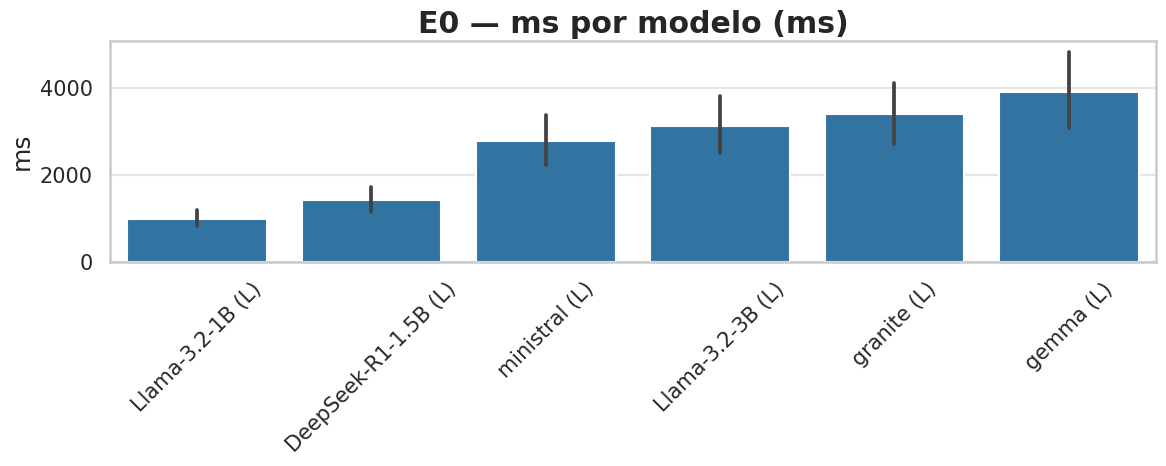

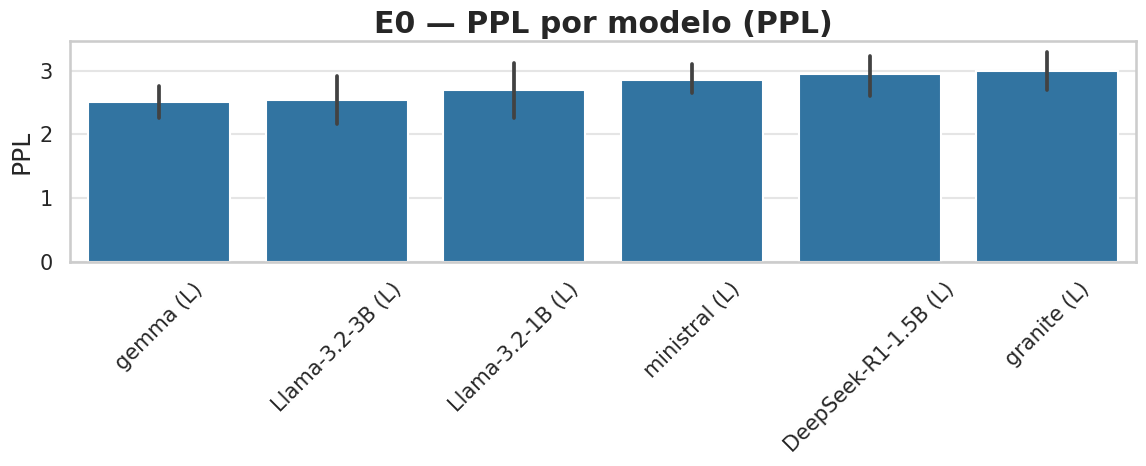

In [40]:
pm_valid = pm_df[~pm_df['is_empty_generation']].copy() if not pm_df.empty else pd.DataFrame()

if not pm_valid.empty:
    for metric, ylabel, unit in [
        ('tokens_per_second',     'tok/s', 'tokens/s'),
        ('words_per_second',      'pal/s', 'palabras/s'),
        ('latency_ms',            'ms',    'ms'),
        ('time_to_first_token_ms','ms',    'ms'),
        ('perplexity',            'PPL',   'PPL'),
    ]:
        if metric in pm_valid.columns:
            _plot_metric(pm_valid, metric, ylabel=ylabel,
                         title=f'E0 \u2014 {ylabel} por modelo', unit_label=unit)
        else:
            print(f'Métrica no disponible: {metric}')
else:
    print('Sin prompts válidos para métricas de inferencia.')


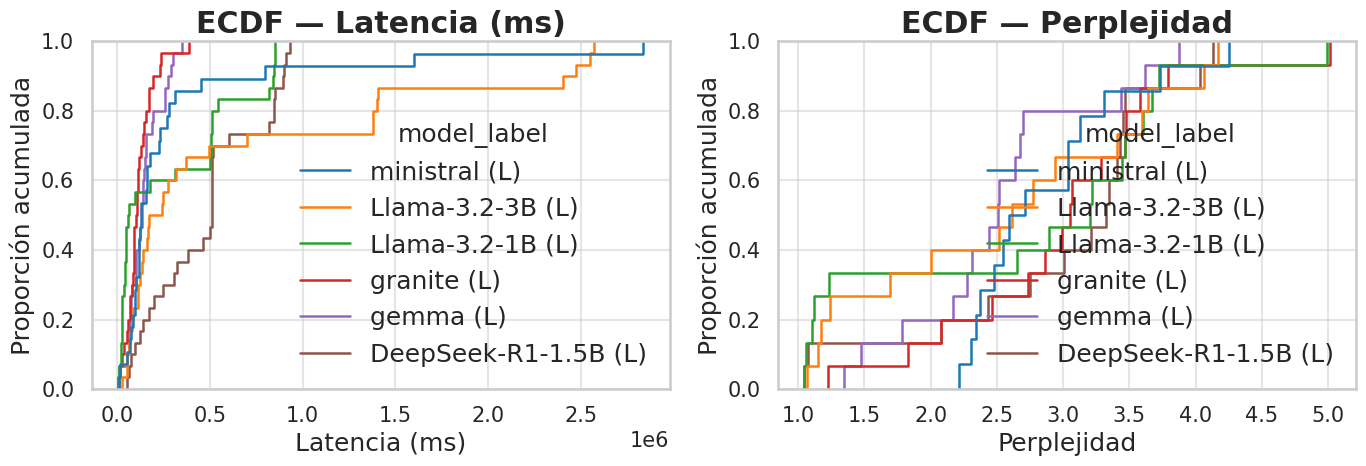

In [41]:
if not pm_valid.empty:
    _ecdf_cols = [(c, lbl) for c, lbl in [
        ('latency_ms', 'Latencia (ms)'),
        ('perplexity', 'Perplejidad'),
    ] if c in pm_valid.columns]
    if _ecdf_cols:
        fig, axes = plt.subplots(1, len(_ecdf_cols), figsize=(7 * len(_ecdf_cols), 5))
        if len(_ecdf_cols) == 1:
            axes = [axes]
        for ax, (col, xlabel) in zip(axes, _ecdf_cols):
            sns.ecdfplot(data=pm_valid.dropna(subset=[col]),
                         x=col, hue='model_label', ax=ax)
            ax.set_xlabel(xlabel)
            ax.set_ylabel('Proporción acumulada')
            ax.set_title(f'ECDF \u2014 {xlabel}')
        fig.tight_layout()
        plt.show()
else:
    print('Sin datos para ECDFs.')


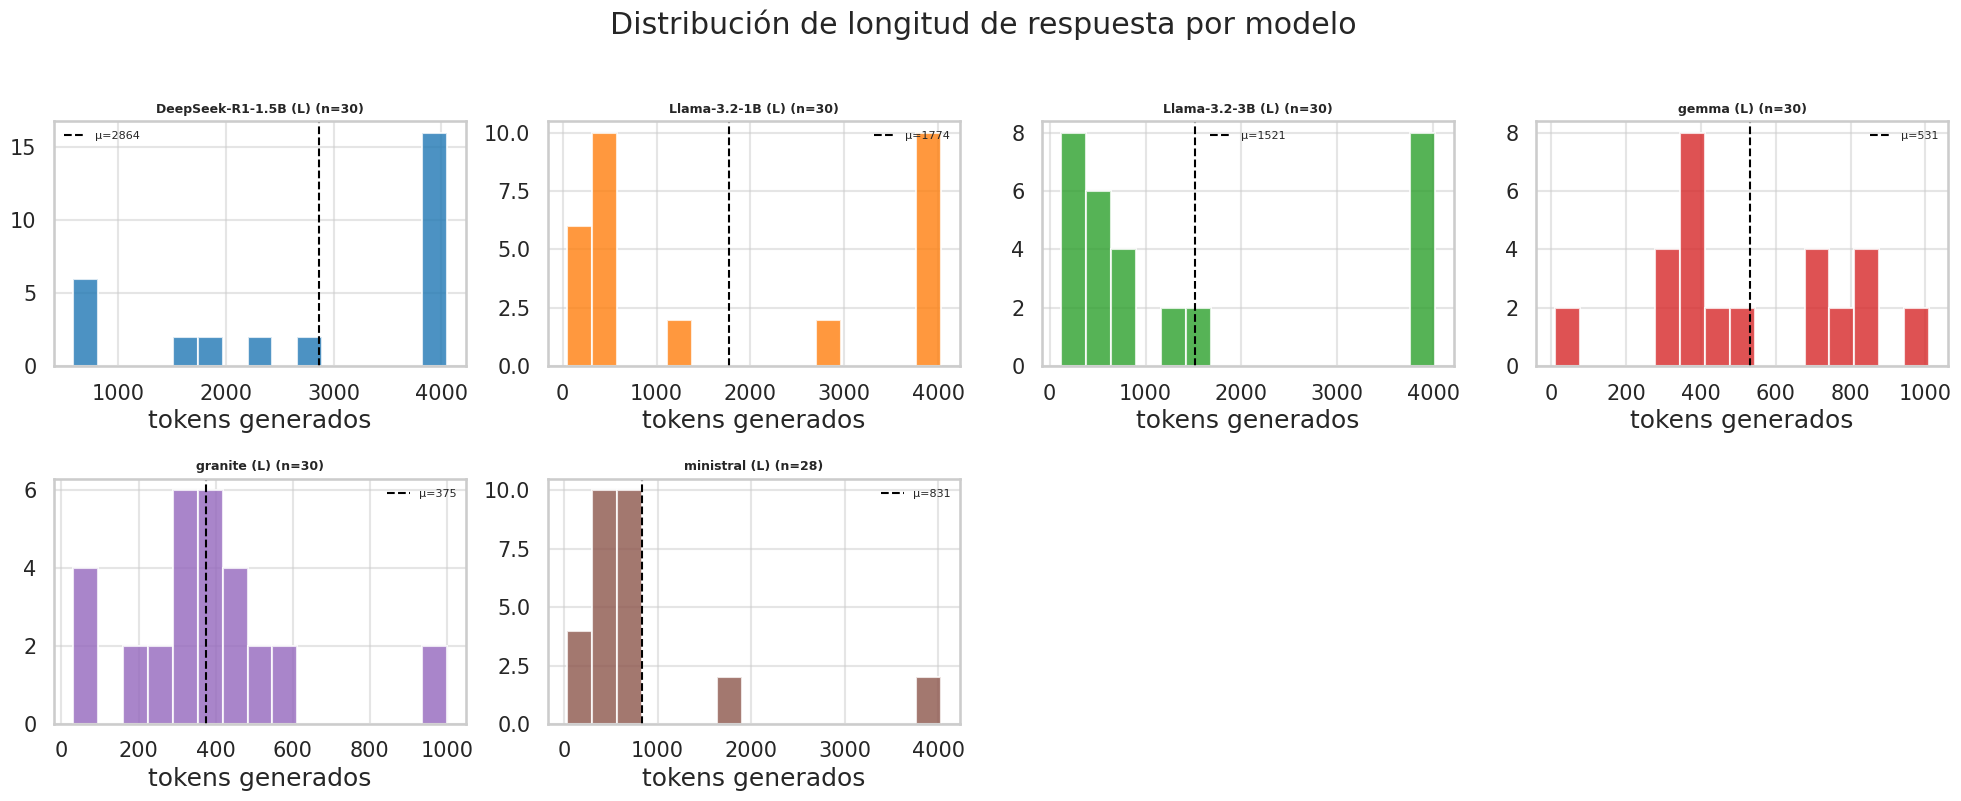


Resumen (tokens generados):


,count,mean,std,min,max
model_label,,,,,
DeepSeek-R1-1.5B (L),30,2863.7,1377.8,574,4059
Llama-3.2-1B (L),30,1773.5,1735.0,42,4035
Llama-3.2-3B (L),30,1520.9,1554.5,115,4023
gemma (L),30,530.9,268.9,9,1011
granite (L),30,375.2,224.7,29,1001
ministral (L),28,831.1,986.5,28,4035


In [42]:
if not pm_valid.empty and 'eval_count' in pm_valid.columns:
    models = sorted(pm_valid['model_label'].unique())
    ncols = min(4, len(models))
    nrows = (len(models) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes_flat = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    for i, model in enumerate(models):
        if i >= len(axes_flat):
            break
        ax = axes_flat[i]
        data = pm_valid[pm_valid['model_label'] == model]['eval_count'].dropna()
        ax.hist(data, bins=15, color=f'C{i}', alpha=0.8, edgecolor='white')
        ax.axvline(data.mean(), ls='--', color='black', lw=1.5,
                   label=f'\u03bc={data.mean():.0f}')
        ax.set_title(f'{model} (n={len(data)})', fontsize=9)
        ax.set_xlabel('tokens generados')
        ax.legend(fontsize=8)
    for j in range(len(models), len(axes_flat)):
        axes_flat[j].set_visible(False)
    fig.suptitle('Distribución de longitud de respuesta por modelo', y=1.01)
    fig.tight_layout()
    plt.show()

    print('\nResumen (tokens generados):')
    display(pm_valid.groupby('model_label')['eval_count']
            .agg(['count', 'mean', 'std', 'min', 'max']).round(1))
else:
    print('Sin datos para distribución de longitud de respuesta.')


## 5. Eficiencia energética y trabajo CPU efectivo

**W_CPU (core·s)**: trabajo computacional efectivo = ∫(f(t)/f_nom)·(CPU(t)/100)·N_cores·dt.  
Análogo a "persona-hora". Con throttling al 50% de frecuencia, W_CPU es
la mitad que a frecuencia nominal en el mismo tiempo real.

**η_CPU**: eficiencia CPU = W_CPU / (N_cores·T). Rango [0,1].

**W_token (core·s/token)**: coste computacional por token generado.

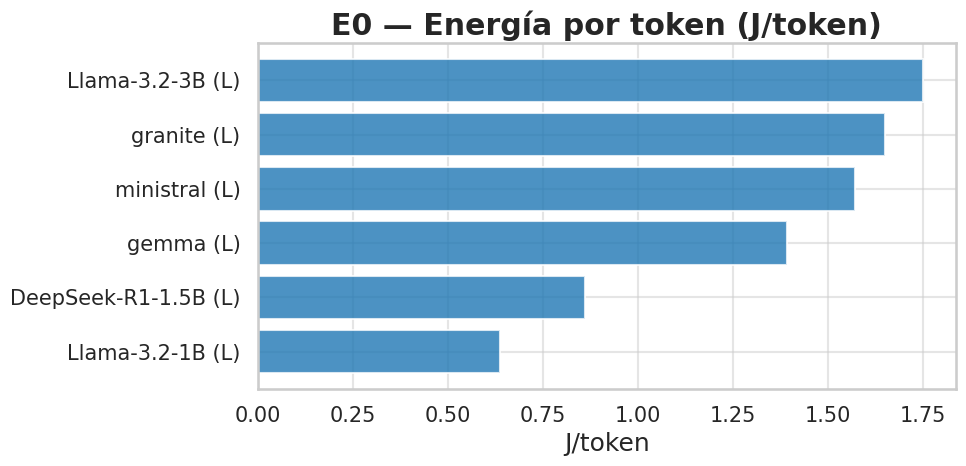

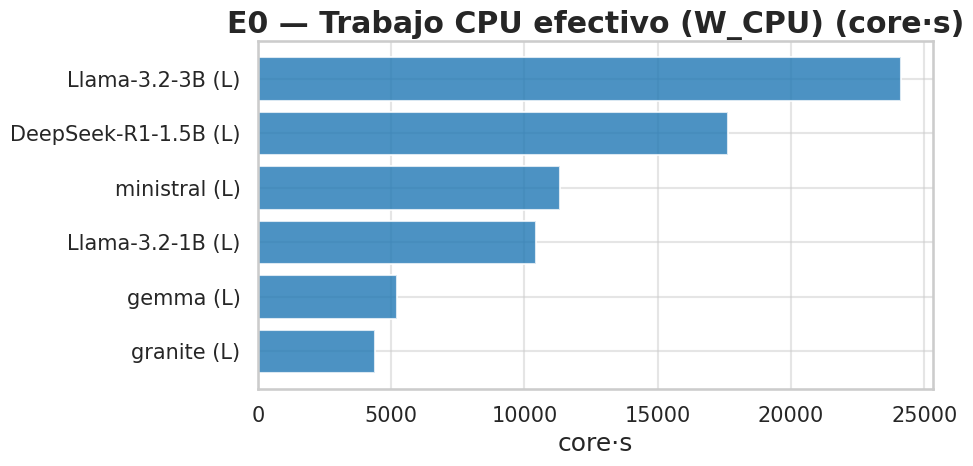

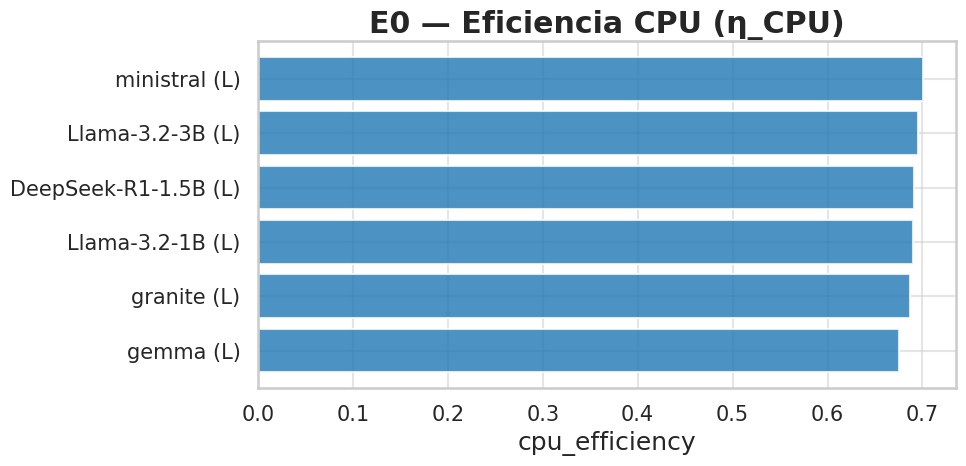

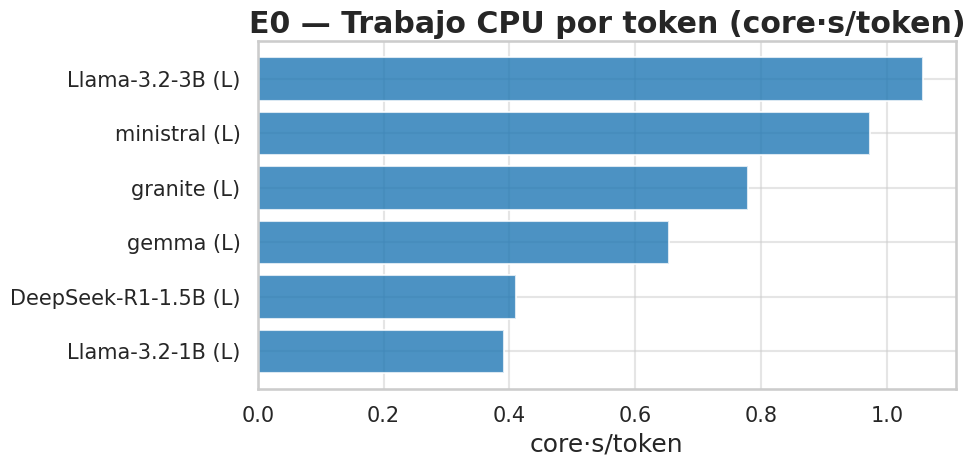

In [43]:
if not summary.empty:
    for metric, title, unit in [
        ('energy_per_token_j',  'Energía por token',           'J/token'),
        ('cpu_work_core_s',     'Trabajo CPU efectivo (W_CPU)', 'core·s'),
        ('cpu_efficiency',      'Eficiencia CPU (η_CPU)',       ''),
        ('cpu_work_per_token',  'Trabajo CPU por token',        'core·s/token'),
    ]:
        if metric in summary.columns:
            _plot_metric(summary, metric, ylabel=unit,
                         title=f'E0 \u2014 {title}', unit_label=unit)
        else:
            print(f'Métrica no disponible en summary: {metric}')
else:
    print('Sin datos de summary para eficiencia energética.')


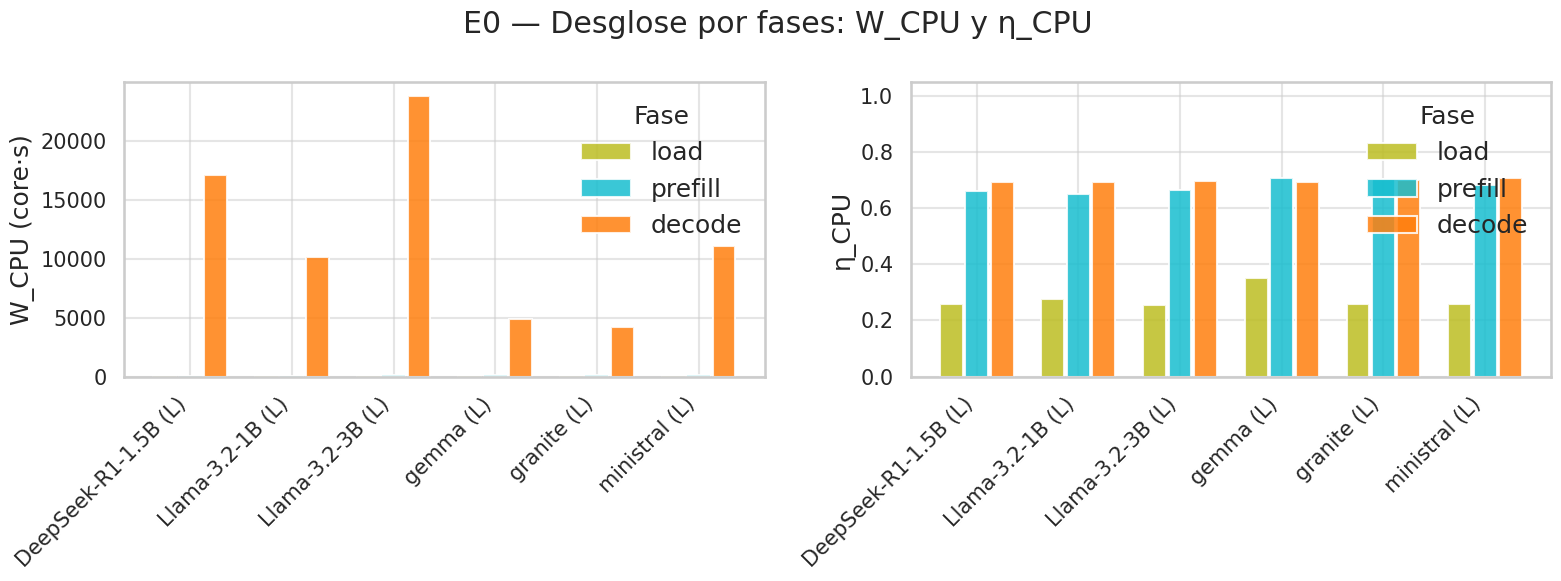

In [44]:
phase_df = coll.cpu_work_by_phase_df() if len(coll.runs) > 0 else pd.DataFrame()

if not phase_df.empty:
    PHASE_ORDER  = ['load', 'prefill', 'decode']
    PHASE_COLORS = {'load': '#bcbd22', 'prefill': '#17becf', 'decode': '#ff7f0e'}
    models = sorted(phase_df['model_label'].unique())
    x = np.arange(len(models))
    width = 0.25

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, (metric, ylabel) in zip(axes, [
        ('cpu_work_core_s', 'W_CPU (core·s)'),
        ('cpu_efficiency',  '\u03b7_CPU'),
    ]):
        for i, phase in enumerate(PHASE_ORDER):
            sub = phase_df[phase_df['phase'] == phase]
            if metric not in sub.columns:
                continue
            vals = [sub[sub['model_label'] == m][metric].mean()
                    if not sub[sub['model_label'] == m].empty else float('nan')
                    for m in models]
            ax.bar(x + (i - 1) * width, vals, width * 0.9,
                   label=phase, color=PHASE_COLORS[phase], alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.set_ylabel(ylabel)
        ax.legend(title='Fase')
        if 'efficiency' in metric:
            ax.set_ylim(0, 1.05)
    fig.suptitle('E0 \u2014 Desglose por fases: W_CPU y \u03b7_CPU')
    fig.tight_layout()
    plt.show()
else:
    print('Sin datos de fases de CPU work (requiere hw data con fases anotadas).')


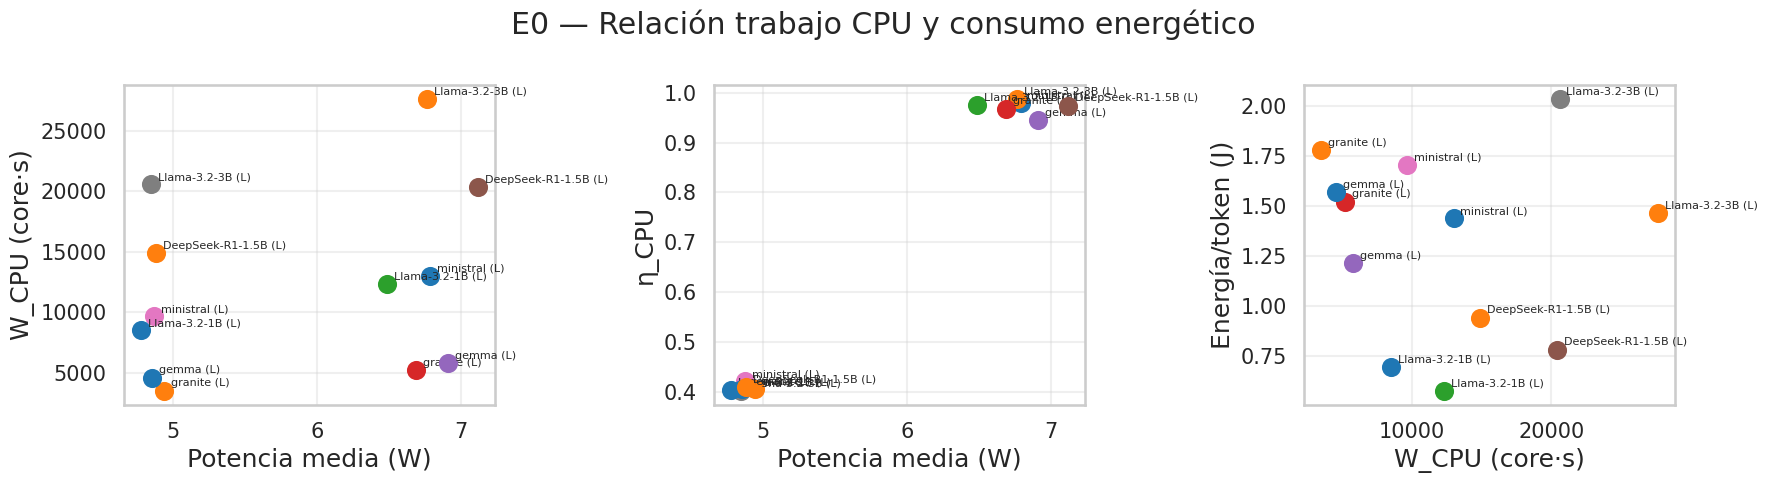

In [45]:
if not summary.empty:
    _needed = ['cpu_work_core_s', 'power_mean_w']
    cpu_e = summary.dropna(subset=[c for c in _needed if c in summary.columns]).copy()
    if not cpu_e.empty and all(c in cpu_e.columns for c in _needed):
        plot_pairs = [
            ('power_mean_w',    'cpu_work_core_s',    'Potencia media (W)', 'W_CPU (core·s)'),
            ('power_mean_w',    'cpu_efficiency',     'Potencia media (W)', '\u03b7_CPU'),
            ('cpu_work_core_s', 'energy_per_token_j', 'W_CPU (core·s)',     'Energía/token (J)'),
        ]
        plot_pairs = [(x, y, xl, yl) for x, y, xl, yl in plot_pairs
                      if x in cpu_e.columns and y in cpu_e.columns]
        if plot_pairs:
            fig, axes = plt.subplots(1, len(plot_pairs),
                                     figsize=(6 * len(plot_pairs), 5))
            if len(plot_pairs) == 1:
                axes = [axes]
            for ax, (x, y, xl, yl) in zip(axes, plot_pairs):
                for i, (_, row) in enumerate(cpu_e.iterrows()):
                    ax.scatter(row[x], row[y], s=150, color=f'C{i % 10}', zorder=3)
                    ax.annotate(row['model_label'], (row[x], row[y]),
                                xytext=(5, 3), textcoords='offset points', fontsize=8)
                ax.set_xlabel(xl)
                ax.set_ylabel(yl)
                ax.grid(True, alpha=0.3)
            fig.suptitle('E0 \u2014 Relación trabajo CPU y consumo energético')
            fig.tight_layout()
            plt.show()
    else:
        print('Sin datos suficientes para gráficas de CPU vs Potencia.')
else:
    print('Sin datos de summary para análisis CPU vs Potencia.')


## 6. Rendimiento combinado y utilización de hardware

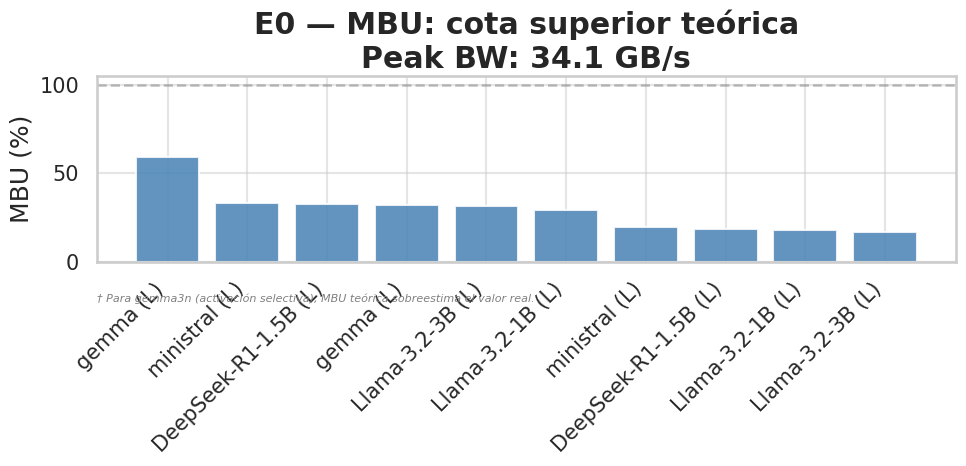

In [46]:
if not summary.empty and 'mbu_pct' in summary.columns:
    from monitorviz.viz.style import TARGET_PEAK_MEMORY_BANDWIDTH_GBs
    mbu_data = summary.dropna(subset=['mbu_pct']).copy()
    if not mbu_data.empty:
        sorted_mbu = mbu_data.sort_values('mbu_pct', ascending=False)
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.bar(range(len(sorted_mbu)), sorted_mbu['mbu_pct'].values,
               color='steelblue', alpha=0.85)
        ax.set_xticks(range(len(sorted_mbu)))
        ax.set_xticklabels(sorted_mbu['model_label'].tolist(), rotation=45, ha='right')
        ax.set_ylabel('MBU (%)')
        ax.set_title(f'E0 — MBU: cota superior teórica\nPeak BW: {TARGET_PEAK_MEMORY_BANDWIDTH_GBs} GB/s')
        ax.axhline(100, ls='--', color='gray', alpha=0.5)
        ax.annotate(
            '† Para gemma3n (activación selectiva), MBU teórica sobreestima el valor real.',
            xy=(0, -0.22), xycoords='axes fraction',
            fontsize=8, style='italic', color='gray'
        )
        plt.tight_layout()
        plt.show()
    else:
        print('Sin datos de MBU disponibles.')
else:
    print('MBU no disponible (requiere model_info con n_kv_heads y bits_per_weight).')

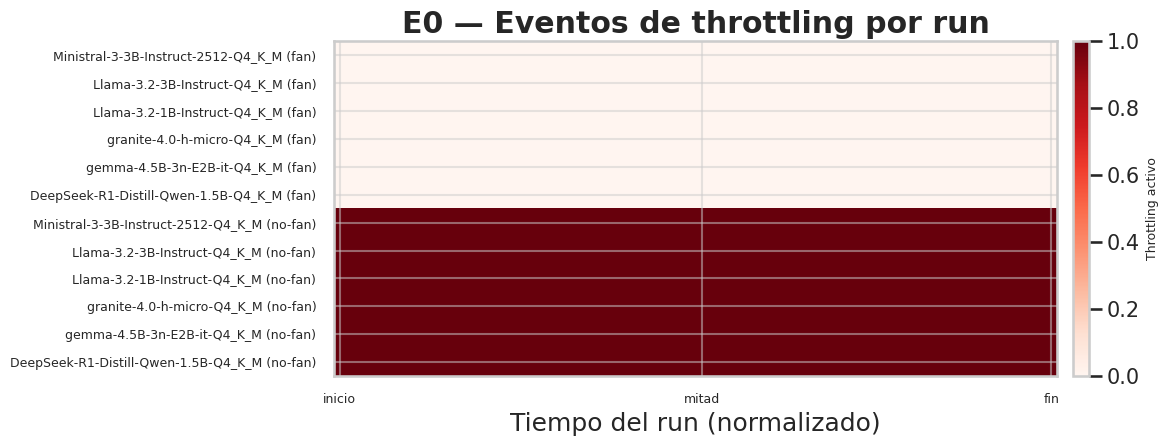

In [47]:
if not hw_df.empty:
    runs_con_hw = [r for r in coll.runs
                   if not hw_df[hw_df['run_id'] == r.run_id].empty]
    if runs_con_hw:
        try:
            fig = throttling_heatmap(hw_df, runs_con_hw,
                                     title='E0 \u2014 Eventos de throttling por run')
            plt.show()
        except Exception as e:
            print(f'throttling_heatmap: {e}')
    else:
        print('Sin runs con datos de hardware para throttling heatmap.')
else:
    print('Sin datos de hardware para throttling heatmap.')


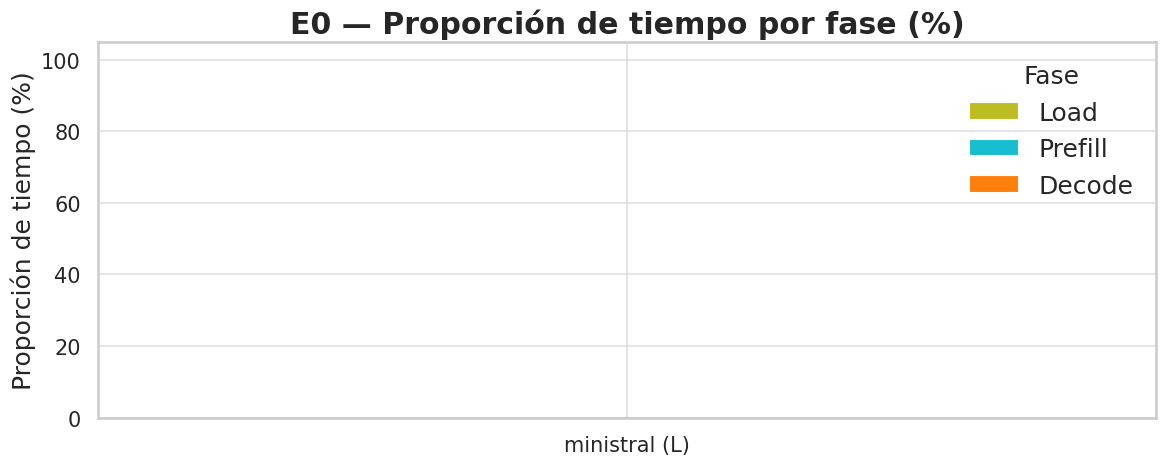

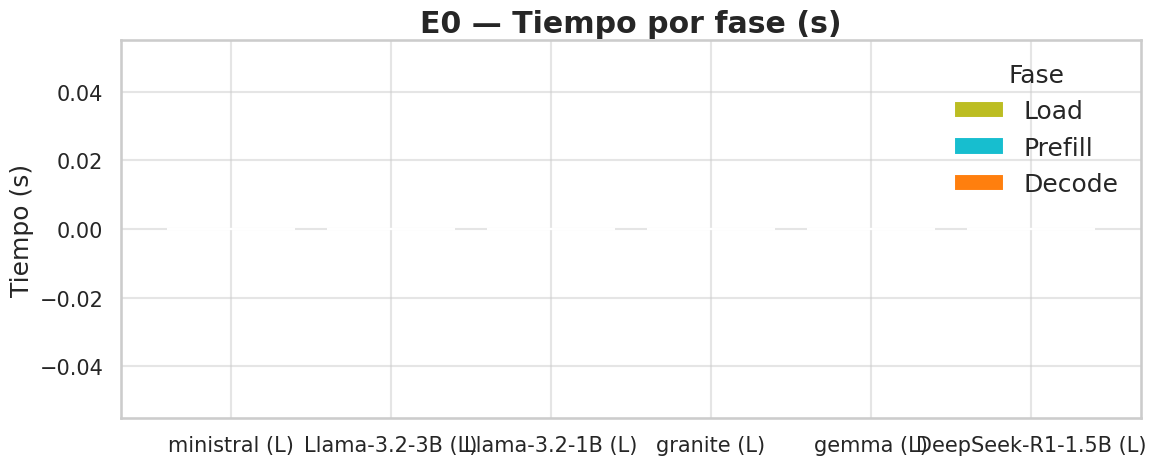

In [48]:
if not summary.empty:
    try:
        fig = phase_breakdown_stacked(summary, normalized=True,
                                      title='E0 \u2014 Proporción de tiempo por fase (%)')
        plt.show()
        fig = phase_breakdown_stacked(summary, normalized=False,
                                      title='E0 \u2014 Tiempo por fase (s)')
        plt.show()
    except Exception as e:
        print(f'phase_breakdown_stacked: {e}')
else:
    print('Sin datos de summary para desglose de fases.')


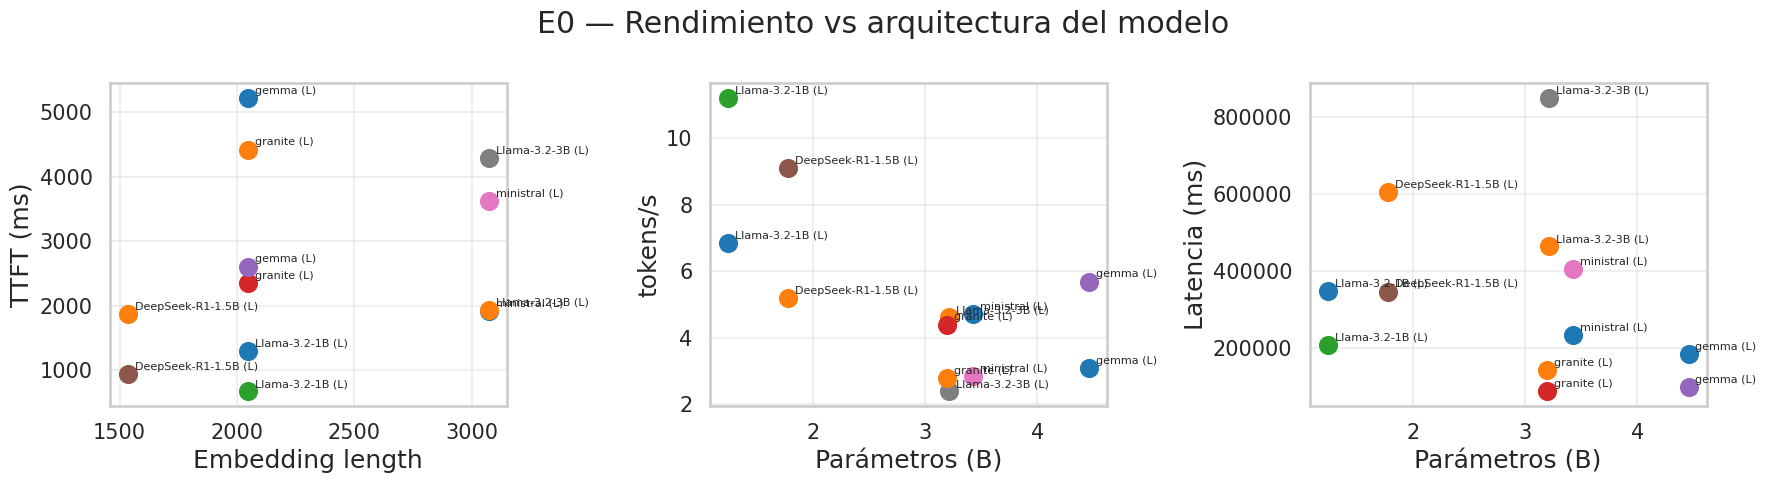

In [49]:
# Extraer n_params y embedding_length de model_info por run_id
if not summary.empty:
    run_map = {r.run_id: r for r in coll.runs}
    n_params_list, emb_len_list = [], []
    for rid in summary['run_id']:
        r = run_map.get(rid)
        mi = (r.summary.model_info or {}) if r else {}
        n_params_list.append(mi.get('n_params', float('nan')))
        emb_len_list.append(mi.get('embedding_length', float('nan')))
    summary_arch = summary.copy()
    summary_arch['n_params_b'] = pd.array(n_params_list, dtype='float64') / 1e9
    summary_arch['emb_len']    = pd.array(emb_len_list, dtype='float64')

    arch = summary_arch.dropna(subset=['n_params_b', 'emb_len'])
    if not arch.empty:
        plot_triples = [
            ('emb_len',   'ttft_ms_mean',       'Embedding length', 'TTFT (ms)'),
            ('n_params_b','tokens_per_s_mean',  'Parámetros (B)',   'tokens/s'),
            ('n_params_b','latency_ms_mean',    'Parámetros (B)',   'Latencia (ms)'),
        ]
        plot_triples = [(x, y, xl, yl) for x, y, xl, yl in plot_triples
                        if y in arch.columns]
        if plot_triples:
            fig, axes = plt.subplots(1, len(plot_triples),
                                     figsize=(6 * len(plot_triples), 5))
            if len(plot_triples) == 1:
                axes = [axes]
            for ax, (x, y, xl, yl) in zip(axes, plot_triples):
                for i, (_, row) in enumerate(arch.iterrows()):
                    ax.scatter(row[x], row[y], s=150, color=f'C{i % 10}', zorder=3)
                    ax.annotate(row['model_label'], (row[x], row[y]),
                                xytext=(5, 3), textcoords='offset points', fontsize=8)
                ax.set_xlabel(xl)
                ax.set_ylabel(yl)
                ax.grid(True, alpha=0.3)
            fig.suptitle('E0 \u2014 Rendimiento vs arquitectura del modelo')
            fig.tight_layout()
            plt.show()
    else:
        print('Sin model_info disponible para gráficas de arquitectura.')
else:
    print('Sin datos de summary para análisis de arquitectura.')


## 7. Trade-offs y análisis multidimensional

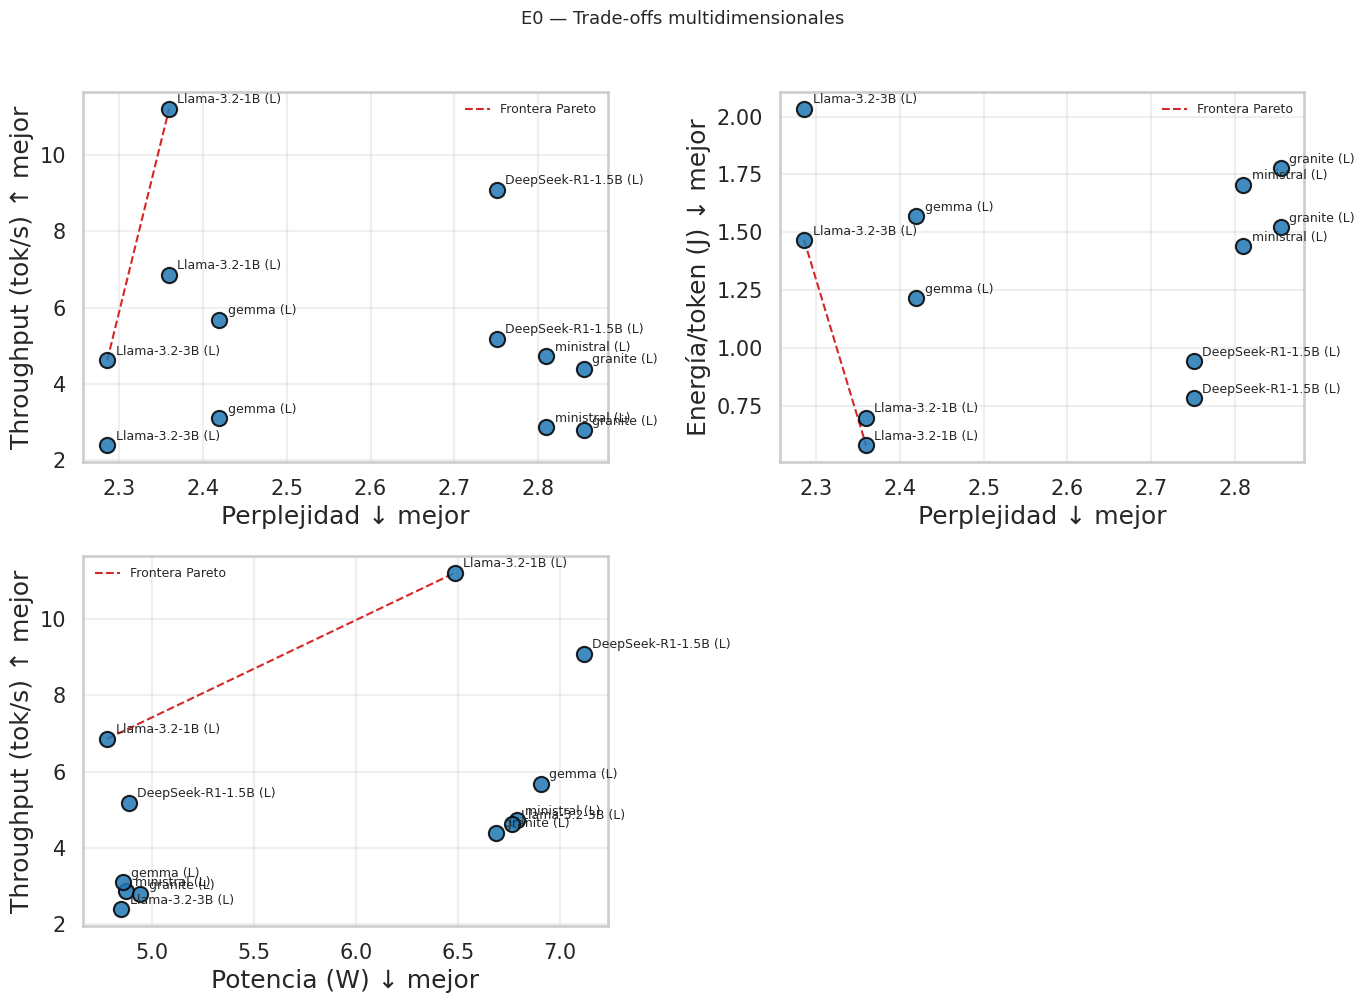

In [50]:
if not summary.empty:
    cols = summary.columns.tolist()
    pairs = []
    if 'perplexity_geomean' in cols and 'tokens_per_s_mean' in cols:
        pairs.append(('perplexity_geomean', 'tokens_per_s_mean',
                       'Perplejidad', 'Throughput (tok/s)', True, False))
    if 'energy_per_token_j' in cols and 'perplexity_geomean' in cols:
        pairs.append(('perplexity_geomean', 'energy_per_token_j',
                       'Perplejidad', 'Energía/token (J)', True, True))
    if 'power_mean_w' in cols and 'tokens_per_s_mean' in cols:
        pairs.append(('power_mean_w', 'tokens_per_s_mean',
                       'Potencia (W)', 'Throughput (tok/s)', True, False))
    if pairs:
        try:
            fig = pareto_panel_multi(summary, pairs,
                                     title='E0 \u2014 Trade-offs multidimensionales')
            plt.show()
        except Exception as e:
            print(f'pareto_panel_multi: {e}')
    else:
        print('Columnas insuficientes para Pareto.')
else:
    print('Sin datos de summary para Pareto.')


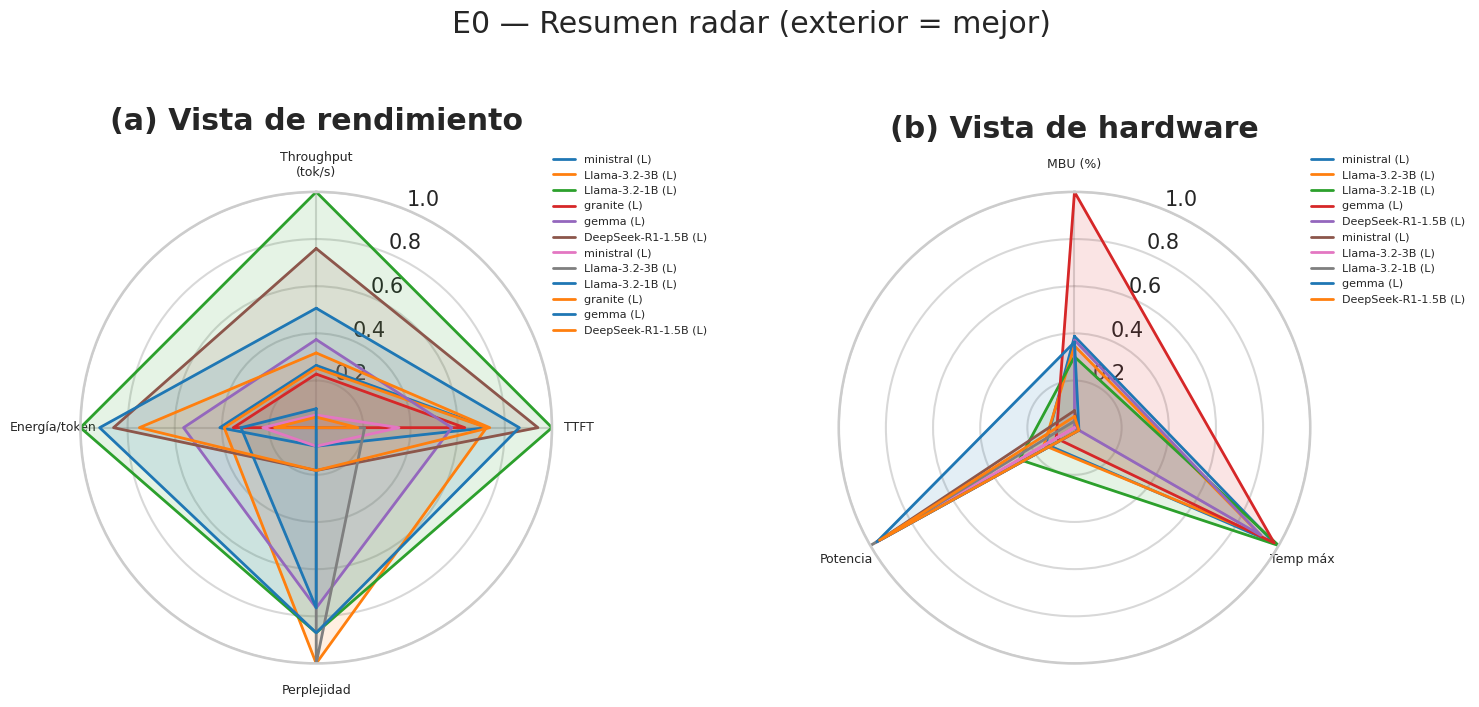

In [51]:
def _radar_chart(df, metrics, title, ax, colors):
    cols = [m[0] for m in metrics]
    data = df.dropna(subset=cols).copy()
    if data.empty:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center',
                transform=ax.transAxes)
        return
    labels = [m[1] for m in metrics]
    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=9)
    ax.set_ylim(0, 1)
    ax.grid(color='gray', alpha=0.3)
    ax.set_title(title, pad=15, fontweight='bold')
    for i, (_, row) in enumerate(data.iterrows()):
        color = colors[i % len(colors)]
        vals = []
        for col, _, higher_is_better in metrics:
            col_min, col_max = data[col].min(), data[col].max()
            rng = col_max - col_min if col_max != col_min else 1.0
            v = (row[col] - col_min) / rng if higher_is_better \
                else (col_max - row[col]) / rng
            vals.append(float(v))
        vals += vals[:1]
        ax.plot(angles, vals, lw=2, color=color, label=row['model_label'])
        ax.fill(angles, vals, alpha=0.12, color=color)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

if not summary.empty:
    perf_metrics = [
        ('tokens_per_s_mean',  'Throughput\n(tok/s)', True),
        ('ttft_ms_mean',       'TTFT',                False),
        ('perplexity_geomean', 'Perplejidad',          False),
        ('energy_per_token_j', 'Energía/token',        False),
    ]
    hw_metrics_r = [
        ('mbu_pct',      'MBU (%)',   True),
        ('temp_max_c',   'Temp máx',  False),
        ('power_mean_w', 'Potencia',  False),
    ]
    perf_avail = [(c, l, h) for c, l, h in perf_metrics if c in summary.columns]
    hw_avail   = [(c, l, h) for c, l, h in hw_metrics_r  if c in summary.columns]
    colors_r   = [f'C{i}' for i in range(10)]

    n_sub = sum([bool(perf_avail), bool(hw_avail)])
    if n_sub > 0:
        fig = plt.figure(figsize=(8 * n_sub, 7))
        sub_idx = 1
        if perf_avail:
            ax1 = fig.add_subplot(1, n_sub, sub_idx, polar=True)
            _radar_chart(summary, perf_avail, '(a) Vista de rendimiento', ax1, colors_r)
            sub_idx += 1
        if hw_avail:
            ax2 = fig.add_subplot(1, n_sub, sub_idx, polar=True)
            _radar_chart(summary, hw_avail, '(b) Vista de hardware', ax2, colors_r)
        fig.suptitle('E0 \u2014 Resumen radar (exterior = mejor)', y=1.02)
        plt.tight_layout()
        plt.show()
else:
    print('Sin datos para diagramas polares.')


In [52]:
if not summary.empty:
    display_cols = [c for c in [
        'model_label', 'fan', 'engine',
        'tokens_per_s_mean', 'words_per_s_mean',
        'latency_ms_mean', 'ttft_ms_mean',
        'perplexity_geomean',
        'temp_max_c', 'throttled_ratio',
        'power_mean_w', 'energy_per_token_j',
        'cpu_work_core_s', 'cpu_efficiency',
        'mbu_pct',
    ] if c in summary.columns]
    display(summary[display_cols].sort_values(['model_label', 'fan']).round(2))
else:
    print('Sin datos de summary para tabla comparativa.')


,model_label,fan,engine,tokens_per_s_mean,words_per_s_mean,latency_ms_mean,ttft_ms_mean,perplexity_geomean,temp_max_c,throttled_ratio,power_mean_w,energy_per_token_j,cpu_work_core_s,cpu_efficiency,mbu_pct
11,DeepSeek-R1-1.5B (L),False,LLAMA,5.18,4.22,606440.15,1876.78,2.75,95.80,1.0,4.88,0.94,14903.45,0.41,18.56
5,DeepSeek-R1-1.5B (L),True,LLAMA,9.10,7.41,347706.20,945.96,2.75,73.25,0.0,7.12,0.78,20381.11,0.97,32.44
8,Llama-3.2-1B (L),False,LLAMA,6.86,5.29,350077.80,1306.11,2.36,95.80,1.0,4.78,0.70,8506.62,0.40,17.73
2,Llama-3.2-1B (L),True,LLAMA,11.22,8.65,210009.44,675.69,2.36,71.05,0.0,6.49,0.58,12338.95,0.98,29.41
7,Llama-3.2-3B (L),False,LLAMA,2.38,1.74,850692.19,4291.24,2.29,96.35,1.0,4.85,2.03,20589.93,0.40,16.53
1,Llama-3.2-3B (L),True,LLAMA,4.62,3.38,464743.50,1938.05,2.29,73.25,0.0,6.77,1.47,27639.94,0.99,31.39
10,gemma (L),False,LLAMA,3.09,2.16,186211.32,5226.37,2.42,95.80,1.0,4.86,1.57,4595.49,0.41,32.07
4,gemma (L),True,LLAMA,5.69,3.95,99654.22,2609.34,2.42,71.60,0.0,6.91,1.21,5813.17,0.95,59.35
9,granite (L),False,LLAMA,2.78,2.15,143151.13,4423.32,2.85,95.80,1.0,4.94,1.78,3529.44,0.41,NaN
3,granite (L),True,LLAMA,4.39,3.39,88585.72,2358.52,2.85,69.40,0.0,6.69,1.52,5248.26,0.97,NaN


## 8. Matriz de correlación de Pearson

Correlaciones entre las métricas clave del experimento.
Permite identificar relaciones entre throughput, temperatura,
potencia, eficiencia y calidad.

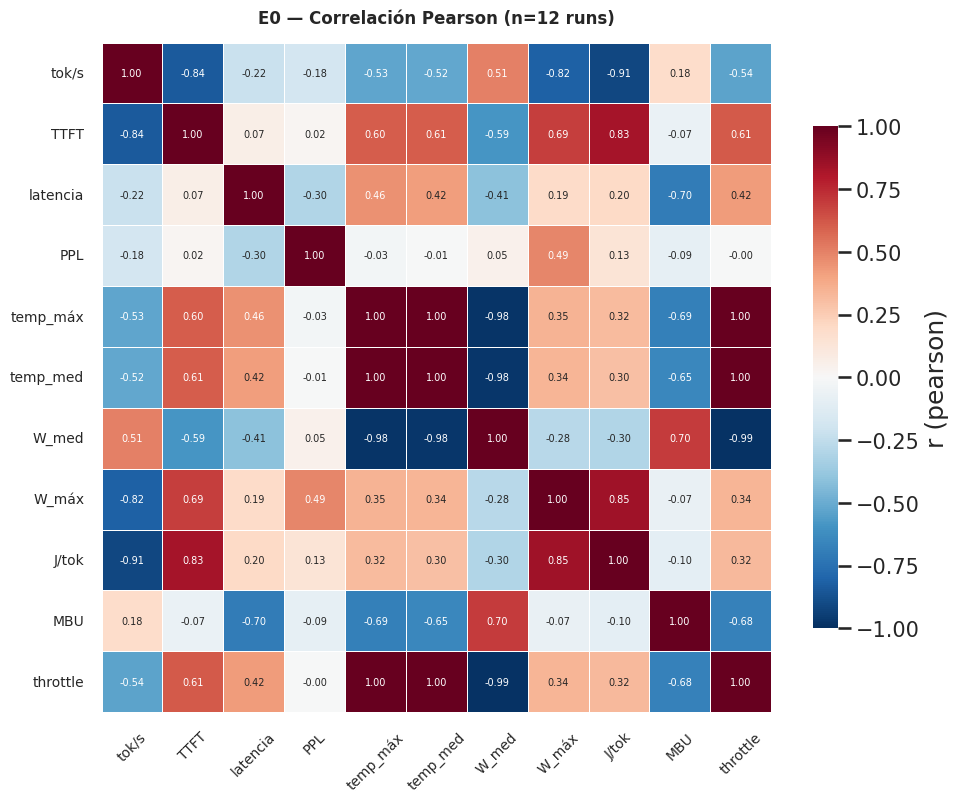

In [53]:
if not summary.empty and len(summary) >= 3:
    try:
        fig = correlation_heatmap(
            summary,
            title=f'E0 \u2014 Correlación Pearson (n={len(summary)} runs)'
        )
        plt.show()
    except Exception as e:
        print(f'correlation_heatmap: {e}')
else:
    n = len(summary) if not summary.empty else 0
    print(f'Se requieren \u22653 runs para la correlación (hay {n}).')


## 9. Análisis específico: impacto de la refrigeración activa

Comparativa directa entre los runs con ventilador (FAN) y sin ventilador
(NOFAN) para cada modelo. La refrigeración activa debería reducir el
throttling térmico y mejorar el throughput sostenido.

In [54]:
/if not summary.empty and 'fan' in summary.columns:
    fan_cols = [c for c in ['tokens_per_s_mean', 'temp_max_c',
                              'throttled_ratio', 'cpu_efficiency']
                if c in summary.columns]
    if fan_cols:
        pivot = summary.pivot_table(
            index='model_label', columns='fan',
            values=fan_cols, aggfunc='mean'
        ).round(2)
        print('Fan (True) vs No-fan (False) por modelo:')
        display(pivot)
    else:
        print('Sin métricas disponibles para comparativa fan/nofan.')
else:
    print('Sin columna fan en summary.')


Fan (True) vs No-fan (False) por modelo:


cpu_efficiency       temp_max_c        throttled_ratio       tokens_per_s_mean       
fan                           False True       False  True            False True              False  True 
model_label                                                                                               
DeepSeek-R1-1.5B (L)           0.41  0.97      95.80  73.25             1.0   0.0              5.18   9.10
Llama-3.2-1B (L)               0.40  0.98      95.80  71.05             1.0   0.0              6.86  11.22
Llama-3.2-3B (L)               0.40  0.99      96.35  73.25             1.0   0.0              2.38   4.62
gemma (L)                      0.41  0.95      95.80  71.60             1.0   0.0              3.09   5.69
granite (L)                    0.41  0.97      95.80  69.40             1.0   0.0              2.78   4.39
ministral (L)                  0.42  0.98      95.80  71.60             1.0   0.0              2.86   4.72

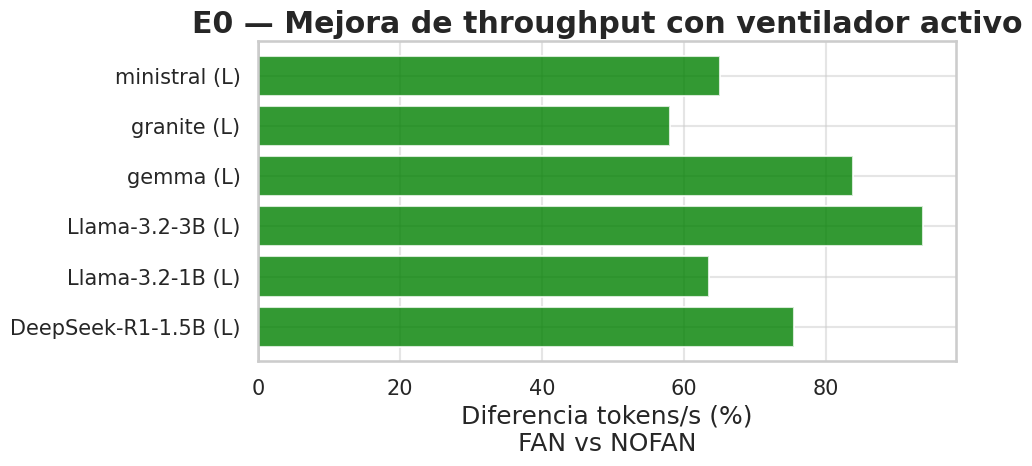


Diferencia absoluta y porcentual (FAN vs NOFAN):


,diff_tok_s,diff_pct
model_label,,
DeepSeek-R1-1.5B (L),3.913,75.5
Llama-3.2-1B (L),4.358,63.5
Llama-3.2-3B (L),2.233,93.7
gemma (L),2.592,83.8
granite (L),1.613,58.0
ministral (L),1.859,65.1


In [55]:
if (not summary.empty and 'fan' in summary.columns
        and 'tokens_per_s_mean' in summary.columns):
    fan_mean   = summary[summary['fan'] == True].groupby('model_label')['tokens_per_s_mean'].mean()
    nofan_mean = summary[summary['fan'] == False].groupby('model_label')['tokens_per_s_mean'].mean()
    common = fan_mean.index.intersection(nofan_mean.index)
    if len(common) > 0:
        diff     = fan_mean.loc[common] - nofan_mean.loc[common]
        diff_pct = diff / nofan_mean.loc[common] * 100
        fig, ax = plt.subplots(figsize=(10, 5))
        colors = ['green' if v > 0 else 'red' for v in diff_pct]
        ax.barh(common.tolist(), diff_pct.values, color=colors, alpha=0.8)
        ax.axvline(0, color='black', lw=1)
        ax.set_xlabel('Diferencia tokens/s (%)\nFAN vs NOFAN')
        ax.set_title('E0 — Mejora de throughput con ventilador activo')
        ax.tick_params(axis='y', rotation=0)
        plt.tight_layout()
        plt.show()

        print('\nDiferencia absoluta y porcentual (FAN vs NOFAN):')
        display(pd.DataFrame({'diff_tok_s': diff.round(3), 'diff_pct': diff_pct.round(1)}))
    else:
        print('Sin modelos comunes entre FAN y NOFAN.')
else:
    print('Sin datos para comparativa fan/nofan.')

In [56]:
if not summary.empty and 'fan' in summary.columns:
    fan_summary = summary[summary['fan'] == True]
    if not fan_summary.empty:
        rank_cols = [c for c in ['model_label', 'tokens_per_s_mean',
                                   'energy_per_token_j', 'throttled_ratio']
                     if c in fan_summary.columns]
        if 'tokens_per_s_mean' in fan_summary.columns:
            ranking = (fan_summary[rank_cols]
                       .sort_values('tokens_per_s_mean', ascending=False)
                       .reset_index(drop=True))
            ranking.index += 1
            print('Ranking de modelos (con ventilador, por throughput):')
            display(ranking.round(3))
        else:
            print('tokens_per_s_mean no disponible para ranking.')
    else:
        print('Sin runs con ventilador (fan=True).')
else:
    print('Sin datos para ranking de modelos.')


Ranking de modelos (con ventilador, por throughput):


,model_label,tokens_per_s_mean,energy_per_token_j,throttled_ratio
1,Llama-3.2-1B (L),11.219,0.578,0.0
2,DeepSeek-R1-1.5B (L),9.097,0.782,0.0
3,gemma (L),5.685,1.215,0.0
4,ministral (L),4.718,1.439,0.0
5,Llama-3.2-3B (L),4.616,1.466,0.0
6,granite (L),4.394,1.522,0.0


## 10. Conclusiones y discusión

### Confirmación de hipótesis
> [Rellenar con los resultados reales una vez ejecutado el notebook]

### Hallazgos principales
1. ...
2. ...
3. ...

### Limitaciones
- El análisis energético no incluye el consumo del sistema de refrigeración.
- La métrica MBU es una cota superior teórica para gemma3n (activación selectiva). En el caso de Granite no se dispone de  la caché kv
- Los prompts de IFEval pueden favorecer ciertos tipos de respuesta.

### Próximos pasos
- Comparar con los resultados del experimento E4 (OLLAMA vs LLAMA.cpp).
- Analizar el impacto de la cuantización en E1.